# Publication Plots — Unified Notebook

**Contents:**
1. Relative Distance Error (binned CSV)
2. Mean Relative Distance Error with Inset (binned CSV)
3. Distance vs Distance Panel Plot (FITS chunks)
4. Normalized RV Error Distribution (FITS)
5. Combined G-mag Distribution (DESI FITS + CSV catalogs)
6. Combined [Fe/H] Distribution (DESI FITS + CSV catalogs)
7. RV Error Histograms (fig5a/5b, hist7a/7b)

DESI columns: ['t5_DESI_COUNT']
Foreground columns: ['t3_220M_COUNT', 't3_17M_COUNT', 't3_33M_COUNT']
Background columns: ['t5_EXCEPT_COUNT', 't5_BOSS_COUNT']
Plot order: ['t5_DESI_COUNT', 't3_220M_COUNT', 't3_17M_COUNT', 't3_33M_COUNT', 't5_EXCEPT_COUNT', 't5_BOSS_COUNT']
Plot saved.


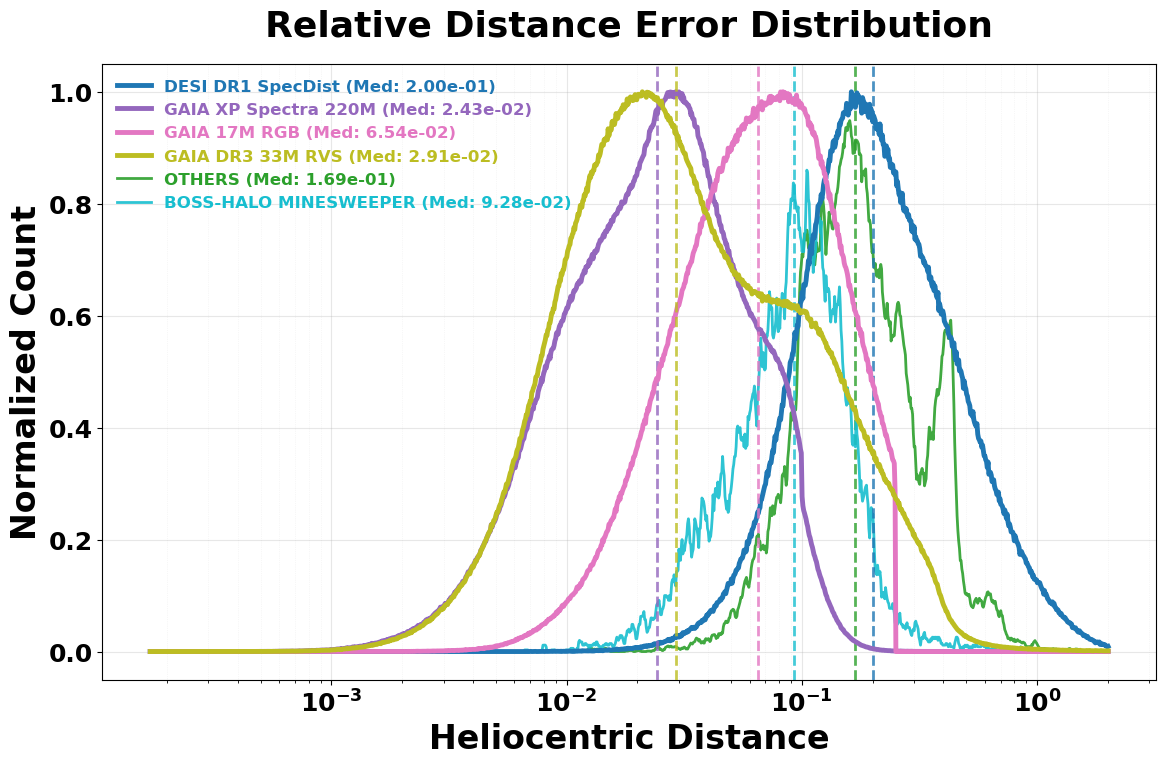

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('relative distance error plotting table.csv')

# Calculate bin centers
df['bin_center'] = np.sqrt(df['LOW'] * df['HIGH'])

# Identify count columns
count_cols = [c for c in df.columns if 'COUNT' in c]

# Create a mapping for nicer legend names (removes T1, T2, T3, etc.)
def clean_name(col):
    name = col.replace('_COUNT', '')
    # Remove T1_, T2_, T3_, T4_, T5_ prefixes (with underscore)
    for i in range(1, 10):
        name = name.replace(f'T{i}_', '')
        name = name.replace(f't{i}_', '')
    # Clean up underscores to spaces
    name = name.replace('_', ' ')
    
    # Apply specific custom names
    name_upper = name.upper().strip()
    
    if 'DESI' in name_upper:
        return 'DESI DR1 SpecDist'
    elif 'EXCEPT' in name_upper or 'OTHER' in name_upper:
        return 'OTHERS'
    elif 'BOSS' in name_upper:
        return 'BOSS-HALO MINESWEEPER'
    elif '220M' in name_upper or '220 M' in name_upper:
        return 'GAIA XP Spectra 220M'
    elif '17M' in name_upper or '17 M' in name_upper:
        return 'GAIA 17M RGB'
    elif '33M' in name_upper or '33 M' in name_upper:
        return 'GAIA DR3 33M RVS'
    else:
        return name.strip()

name_map = {c: clean_name(c) for c in count_cols}

# Publication-quality plot setup
plt.figure(figsize=(12, 8))

# Set font sizes
plt.rcParams.update({
    'font.size': 18,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.labelsize': 22,
    'axes.titlesize': 24,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 12,
    'legend.title_fontsize': 18,
    'lines.linewidth': 2.5
})

# Define colors 
colors = plt.cm.tab10(np.linspace(0, 1, len(count_cols)))
col_color_map = {col: colors[i] for i, col in enumerate(count_cols)}

# ---------------------------------------------------------
# STRICT LAYERING CONFIGURATION
# ---------------------------------------------------------
# 1. Background Group (Boss, Except) -> Low Z-Order
# 2. Foreground Group (All Others)   -> High Z-Order
background_names = ['BOSS_COUNT', 'EXCEPT_COLUMN_COUNT']

def weighted_median(values, weights):
    """Calculate weighted median skipping NaNs"""
    valid_mask = ~np.isnan(weights)
    values = np.array(values)[valid_mask]
    weights = np.array(weights)[valid_mask]
    
    sorted_indices = np.argsort(values)
    sorted_values = values[sorted_indices]
    sorted_weights = weights[sorted_indices]
    
    cumsum = np.cumsum(sorted_weights)
    total = cumsum[-1]
    
    median_idx = np.searchsorted(cumsum, total / 2.0)
    return sorted_values[median_idx]

# ---------------------------------------------------------
# SEPARATE COLUMNS INTO DESI, FOREGROUND, AND BACKGROUND
# ---------------------------------------------------------
desi_cols = [col for col in count_cols if 'DESI' in col.upper()]
background_cols = [col for col in count_cols 
                   if any(name in col.upper() for name in ['BOSS', 'EXCEPT'])]
foreground_cols = [col for col in count_cols 
                   if col not in desi_cols and col not in background_cols]

# Plot order: DESI first, then FOREGROUND, then BACKGROUND (Boss/Except last)
plot_order = desi_cols + foreground_cols + background_cols

print("DESI columns:", desi_cols)
print("Foreground columns:", foreground_cols)
print("Background columns:", background_cols)
print("Plot order:", plot_order)
# Plot in specified order
plot_handles = []
plot_labels = []

for col in plot_order:
    x_values = df['bin_center']
    is_background = any(name in col.upper() for name in ['BOSS', 'EXCEPT'])
    
    if is_background:
        # --- BACKGROUND SETTINGS (Boss / Except) ---
        layer_order = 2  
        line_width = 2.0  
        alpha_val = 0.9   
        y_values = df[col].rolling(window=5, center=True, min_periods=1).mean()
    else:
        # --- FOREGROUND SETTINGS (DESI and others) ---
        layer_order = 10 
        line_width = 3.5  
        alpha_val = 1.0   
        y_values = df[col]

    # Calculate Median for Label
    median_x = weighted_median(x_values, y_values)
    label_text = f"{name_map[col]} (Med: {median_x:.2e})"
    
    # PLOT THE CURVE
    line, = plt.plot(x_values, y_values, 
                     label=label_text, 
                     linewidth=line_width, 
                     alpha=alpha_val,
                     color=col_color_map[col],
                     zorder=layer_order)
    
    plot_handles.append(line)
    plot_labels.append(label_text)
    
    # PLOT THE VERTICAL MEDIAN LINE
    plt.axvline(x=median_x, color=col_color_map[col], linestyle='--', 
                linewidth=2.0, alpha=0.8, 
                zorder=layer_order)

# Formatting
plt.xscale('log')
plt.xlabel('Heliocentric Distance', fontsize=24, fontweight='bold')
plt.ylabel('Normalized Count', fontsize=24, fontweight='bold')
plt.title('Relative Distance Error Distribution', fontsize=26, fontweight='bold', pad=20)

# ---------------------------------------------------------
# LEGEND CUSTOMIZATION (with explicit handle/label order)
# ---------------------------------------------------------
leg = plt.legend(handles=plot_handles, labels=plot_labels,
                 title='', 
                 loc='upper left',  
                 frameon=False ,
                 fancybox=False,
                 shadow=False,
                 framealpha=0.0)

# COLORIZE LEGEND TEXT
for line, text in zip(leg.get_lines(), leg.get_texts()):
    text.set_color(line.get_color())

# Grid styling (zorder=1 pushes it to the absolute back)
plt.grid(True, which="both", ls="-", alpha=0.3, linewidth=0.8, zorder=1)
plt.grid(True, which="minor", ls=":", alpha=0.2, linewidth=0.5, zorder=1)

# Make tick labels bold
ax = plt.gca()
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.savefig('relative_distance_error_plot.png', dpi=300, bbox_inches='tight')
print("Plot saved.")
plt.show()

Generating elegant histogram plots...

[1/2] Creating plot for Distance > 10 kpc...
✓ Saved: relative_error_gt10kpc.png
✓ Saved: relative_error_gt10kpc.pdf


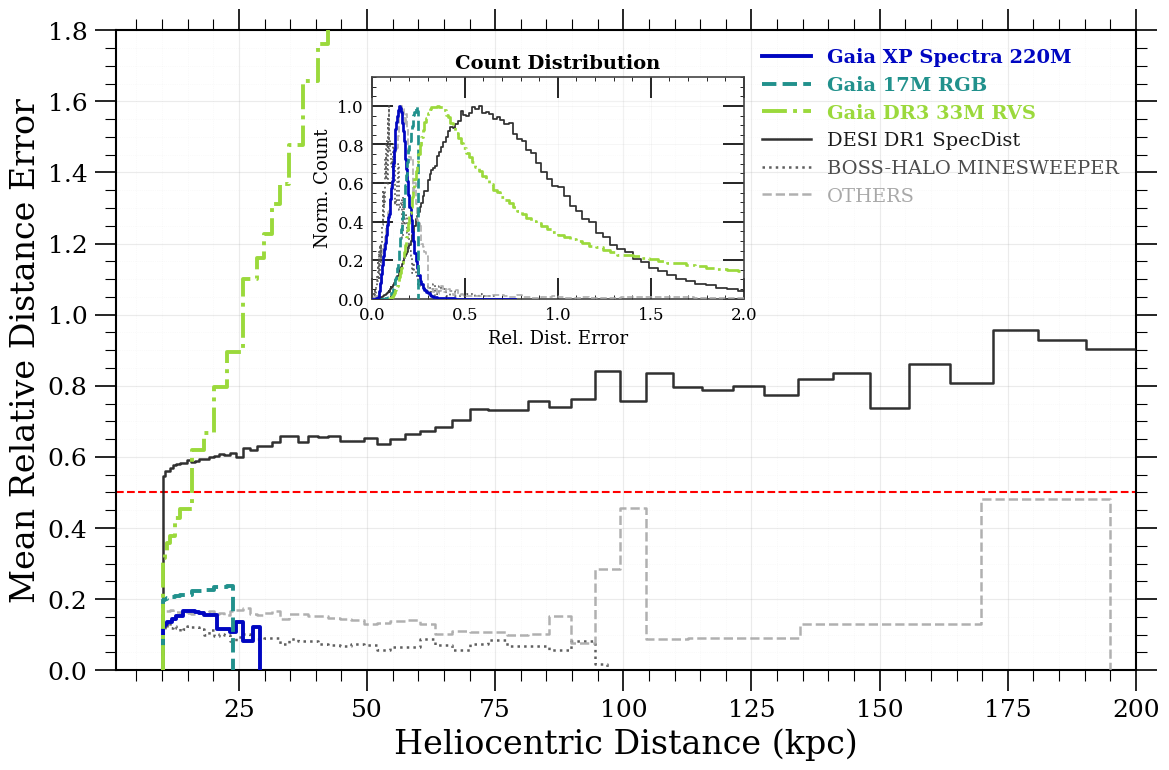


[2/2] Creating plot for Distance < 10 kpc...
✓ Saved: relative_error_lt10kpc.png
✓ Saved: relative_error_lt10kpc.pdf


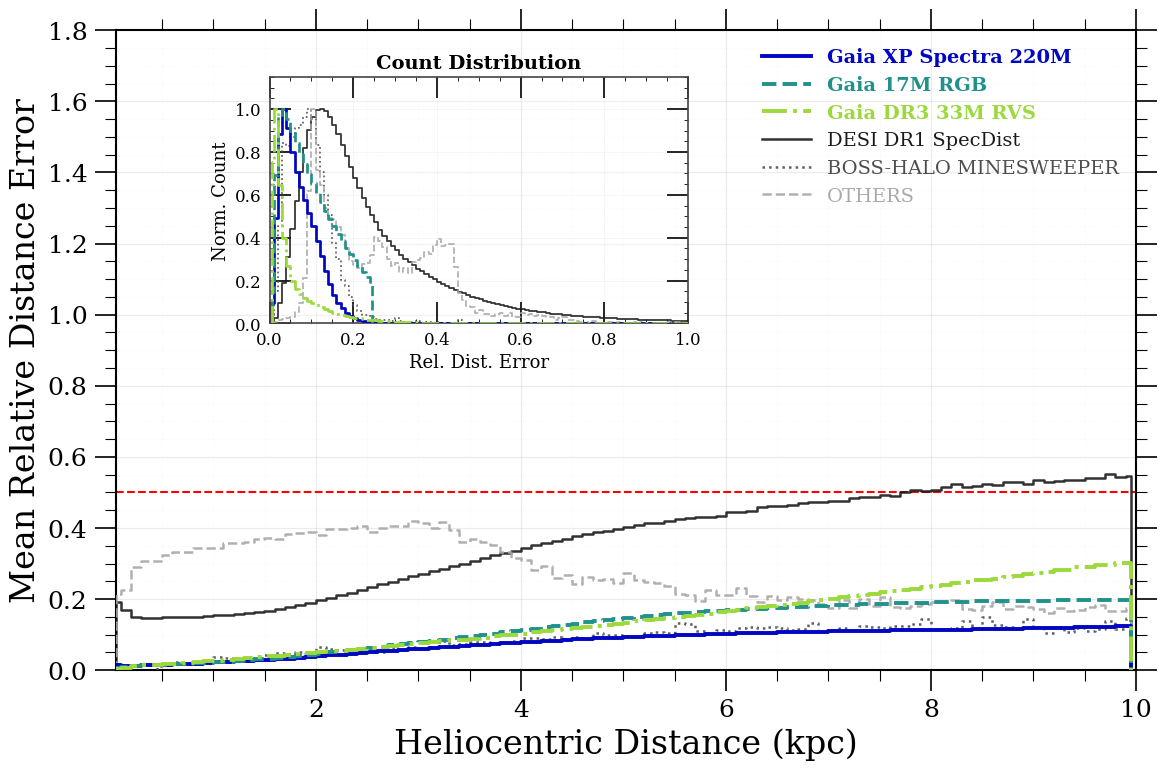


✓ All plots generated successfully!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =============================================================================
# CONFIGURE FONTS (mathtext for elegant rendering)
# =============================================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Times'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'axes.labelsize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 10,
    'axes.unicode_minus': False,
    'xtick.major.size': 15,
    'xtick.minor.size': 8,
    'ytick.major.size': 15,
    'ytick.minor.size': 8,
    'xtick.major.width': 1.2,
    'xtick.minor.width': 0.8,
    'ytick.major.width': 1.2,
    'ytick.minor.width': 0.8,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.5,
})

# =============================================================================
# LOAD DATA
# =============================================================================
# Mean data
mean_gt10 = pd.read_csv('histogram_gt_10_mean.csv')
mean_lt10 = pd.read_csv('histogram_lt_10_mean.csv')

# Count data
count_gt10 = pd.read_csv('histogram1_gt10_count.csv')
count_lt10 = pd.read_csv('histogram2_lt10_count.csv')

# Calculate bin centers (geometric mean for log-scale plotting)
def safe_bin_center(df):
    # Use geometric mean for positive values, arithmetic for others
    low = df['LOW'].values
    high = df['HIGH'].values
    centers = np.zeros(len(low))
    for i in range(len(low)):
        if low[i] > 0 and high[i] > 0:
            centers[i] = np.sqrt(low[i] * high[i])
        else:
            centers[i] = (low[i] + high[i]) / 2
    return centers

mean_gt10['bin_center'] = safe_bin_center(mean_gt10)
mean_lt10['bin_center'] = safe_bin_center(mean_lt10)
count_gt10['bin_center'] = safe_bin_center(count_gt10)
count_lt10['bin_center'] = safe_bin_center(count_lt10)

# Filter valid data
mean_gt10 = mean_gt10[mean_gt10['bin_center'] > 0]
mean_lt10 = mean_lt10[mean_lt10['bin_center'] > 0]
count_gt10 = count_gt10[count_gt10['bin_center'] > 0]
count_lt10 = count_lt10[count_lt10['bin_center'] > 0]

# =============================================================================
# DEFINE COLORS - GAIA XP NOW BLUE, ADJUSTED GRAYS
# =============================================================================
viridis = plt.cm.viridis
gaia_colors = {
    '220M': "#0006C1",           # Blue for Gaia XP (changed from viridis)
    '17M': viridis(0.50),        # Mid viridis (teal)
    '33M': viridis(0.85),        # Light viridis (yellow-green)
}

non_gaia_colors = {
    'DESI': '#1a1a1a',           # Near black
    'BOSS': '#4d4d4d',           # Dark gray
    'OTHERS': '#a8a8a8',         # Lighter gray (changed from #808080)
}

# Line styles for different surveys
line_styles = {
    '220M': '-',                 # Solid
    '17M': '--',                 # Dashed
    '33M': '-.',                 # Dash-dot
    'DESI': '-',                 # Solid
    'BOSS': ':',                 # Dotted
    'OTHERS': '--',              # Dashed
}

# Survey properties
survey_labels = {
    'DESI': 'DESI DR1 SpecDist',
    'BOSS': 'BOSS-HALO MINESWEEPER',
    'OTHERS': 'OTHERS',
    '33M': 'Gaia DR3 33M RVS',
    '17M': 'Gaia 17M RGB',
    '220M': 'Gaia XP Spectra 220M',
}

survey_order = ['220M', '17M', '33M', 'DESI', 'BOSS', 'OTHERS']
gaia_surveys = ['220M', '17M', '33M']
non_gaia_surveys = ['DESI', 'BOSS', 'OTHERS']


def get_color(survey):
    return gaia_colors.get(survey, non_gaia_colors.get(survey, 'black'))


def get_linestyle(survey):
    return line_styles.get(survey, '-')


def get_linewidth(survey):
    return 2.8 if survey in gaia_surveys else 1.8


def get_alpha(survey):
    return 1.0 if survey in gaia_surveys else 0.9


# =============================================================================
# COLUMN MAPPING FOR < 10 kpc
# =============================================================================
mean_lt10_cols = {
    'DESI': 't1_desi<10_mean_DISTERR/DIST',
    'BOSS': 't1_boss<10_mean_DISTERR/DIST',
    'OTHERS': 't1_others <10_mean_DISTERR/DIST',
    '33M': 't2_not_33m>10_mean_parallax_error/parallax',
    '17M': 't3_not_17m>10_mean_parallax_error/parallax',
    '220M': 't3_not_220m>10_mean_stellar_params_err[4]/stellar_params_est[4]',
}

count_lt10_cols = {
    'DESI': 't1_desi<10_COUNT',
    'BOSS': 't1_boss<10_COUNT',
    'OTHERS': 't1_others <10_COUNT',
    '33M': 't2_not_33m>10_COUNT',
    '17M': 't3_not_17m>10_COUNT',
    '220M': 't3_not_220m>10_COUNT',
}

# =============================================================================
# COLUMN MAPPING FOR > 10 kpc
# =============================================================================
mean_gt10_cols = {
    'DESI': 't1_desi>10_mean_DISTERR/DIST',
    'BOSS': 't1_boss_mean_DISTERR/DIST',
    'OTHERS': 't1_others_mean_DISTERR/DIST',
    '33M': 't5_33m>10_mean_parallax_error/parallax',
    '17M': 't6_17m>10_mean_parallax_error/parallax',
    '220M': 't6_220m>10_mean_stellar_params_err[4]/stellar_params_est[4]',
}

count_gt10_cols = {
    'DESI': 't1_desi>10_COUNT',
    'BOSS': 't1_boss_COUNT',
    'OTHERS': 't1_others_COUNT',
    '33M': 't5_33m>10_COUNT',
    '17M': 't6_17m>10_COUNT',
    '220M': 't6_220m>10_COUNT',
}


def create_elegant_plot(mean_df, count_df, mean_cols, count_cols,
                        title_suffix, output_filename, x_is_distance=False,
                        x_min_main=None, x_max_main=None, y_max_main=None,
                        inset_x=0.02, inset_y=0.98, inset_width="42%", inset_height="38%", inset_x_max=1.0):
    """
    Create publication-quality plot with mean as main and count as inset.
    
    Parameters:
    -----------
    mean_df : DataFrame with mean data
    count_df : DataFrame with count data  
    mean_cols : dict mapping survey names to mean column names
    count_cols : dict mapping survey names to count column names
    title_suffix : str, either '< 10 kpc' or '> 10 kpc'
    output_filename : str, output file name
    x_is_distance : bool, if True, x-axis is distance; if False, x-axis is relative error
    x_min_main : float, optional minimum x-axis value for main plot
    x_max_main : float, optional maximum x-axis value for main plot
    y_max_main : float, optional maximum y-axis value for main plot
    inset_x : float, x position of inset (0-1, from left edge)
    inset_y : float, y position of inset (0-1, from bottom edge)
    inset_width : str, width of inset (e.g., "42%")
    inset_height : str, height of inset (e.g., "38%")
    """
    
    fig, ax_main = plt.subplots(figsize=(12, 8))
    
    # Create inset axes with direct position control
    # inset_x, inset_y are in axes coordinates (0-1)
    # Convert percentage strings to floats for width/height
    w = float(inset_width.replace('%', '')) / 100
    h = float(inset_height.replace('%', '')) / 100
    
    # Get the main axes position in figure coordinates
    bbox = ax_main.get_position()
    
    # Calculate inset position in figure coordinates
    inset_left = bbox.x0 + inset_x * bbox.width
    inset_bottom = bbox.y0 + (inset_y - h) * bbox.height
    inset_w = w * bbox.width
    inset_h = h * bbox.height
    
    ax_inset = fig.add_axes([inset_left, inset_bottom, inset_w, inset_h])
    
    handles_main = []
    labels_main = []
    
    # =========================================================================
    # PLOT MAIN AXES (MEAN DATA)
    # =========================================================================
    for survey in survey_order:
        color = get_color(survey)
        lw = get_linewidth(survey)
        alpha = get_alpha(survey)
        ls = get_linestyle(survey)
        label = survey_labels[survey]
        
        if survey in mean_cols and mean_cols[survey] in mean_df.columns:
            x_mean = mean_df['bin_center']
            y_mean = mean_df[mean_cols[survey]]
            
            # Filter out zeros and NaNs
            mask = (y_mean > 0) & (~np.isnan(y_mean))
            if mask.sum() > 2:
                x_data = x_mean[mask].values
                y_data = y_mean[mask].values
                
                # Add points at start and end to create vertical lines
                x_plot = np.concatenate([[x_data[0]], x_data, [x_data[-1]]])
                y_plot = np.concatenate([[0], y_data, [0]])
                
                line, = ax_main.step(x_plot, y_plot, where='mid',
                                     color=color, linewidth=lw, alpha=alpha,
                                     linestyle=ls,
                                     label=label, zorder=10 if survey in gaia_surveys else 5)
                handles_main.append(line)
                labels_main.append(label)
    
    # =========================================================================
    # PLOT INSET AXES (COUNT DATA)
    # =========================================================================
    for survey in survey_order:
        color = get_color(survey)
        lw = get_linewidth(survey) * 0.7
        alpha = get_alpha(survey)
        ls = get_linestyle(survey)
        
        if survey in count_cols and count_cols[survey] in count_df.columns:
            x_count = count_df['bin_center']
            y_count = count_df[count_cols[survey]]
            
            # Filter out zeros and NaNs
            mask = (y_count > 0) & (~np.isnan(y_count))
            if mask.sum() > 2:
                x_data = x_count[mask].values
                y_data = y_count[mask].values
                
                # Add points at start and end to create vertical lines
                x_plot = np.concatenate([[x_data[0]], x_data, [x_data[-1]]])
                y_plot = np.concatenate([[0], y_data, [0]])
                
                ax_inset.step(x_plot, y_plot, where='mid',
                             color=color, linewidth=lw, alpha=alpha,
                             linestyle=ls,
                             zorder=10 if survey in gaia_surveys else 5)
    
    # =========================================================================
    # MAIN AXES FORMATTING
    # =========================================================================
    #ax_main.set_xscale('log')
    
    if x_is_distance:
        ax_main.set_xlabel(r'Heliocentric Distance (kpc)', fontsize=24, fontweight='medium')
    else:
        ax_main.set_xlabel(r'Heliocentric Distance (kpc)', fontsize=24, fontweight='medium')
    
    ax_main.set_ylabel(r'Mean Relative Distance Error', fontsize=24, fontweight='medium')
    #ax_main.set_title(f'Distance {title_suffix}', fontsize=28, pad=15, fontweight='bold')
    
    # Enable minor ticks
    ax_main.minorticks_on()
    
    # Add horizontal red line at y=0.5
    ax_main.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, zorder=2)
    
    # Grid styling
    ax_main.grid(True, which="major", ls="-", alpha=0.25, linewidth=0.8, zorder=1)
    ax_main.grid(True, which="minor", ls=":", alpha=0.12, linewidth=0.5, zorder=1)
    
    # Auto-adjust main axes limits
    all_x, all_y = [], []
    for survey in survey_order:
        if survey in mean_cols and mean_cols[survey] in mean_df.columns:
            y = mean_df[mean_cols[survey]]
            x = mean_df['bin_center']
            mask = (y > 0) & (~np.isnan(y))
            if mask.sum() > 0:
                all_x.extend(x[mask].tolist())
                all_y.extend(y[mask].tolist())
    
    if all_x and all_y:
        if x_min_main is not None:
            x_min = x_min_main
        else:
            x_min = max(min(all_x) * 0.7, 1e-4)
        if x_max_main is not None:
            x_max = x_max_main
        else:
            x_max = max(all_x) * 1.5
        if y_max_main is not None:
            y_max = y_max_main
        else:
            y_max = min(max(all_y) * 1.15, 1.2)
        ax_main.set_xlim([x_min, x_max])
        ax_main.set_ylim([0, y_max])
    
    # =========================================================================
    # LEGEND WITH COLORED TEXT (top right corner)
    # =========================================================================
    leg = ax_main.legend(handles=handles_main, labels=labels_main,
                         loc='upper right', frameon=False,
                         fontsize=14, handlelength=2.5)
    
    for line, text in zip(leg.get_lines(), leg.get_texts()):
        text.set_color(line.get_color())
        if any(g in text.get_text() for g in ['Gaia', '220M', '17M', '33M']):
            text.set_fontweight('bold')
    
    # =========================================================================
    # INSET AXES FORMATTING
    # =========================================================================
    #ax_inset.set_xscale('log')
    ax_inset.minorticks_on()
    ax_inset.set_xlabel(r'Rel. Dist. Error', fontsize=13, fontweight='medium')
    ax_inset.set_ylabel(r'Norm. Count', fontsize=13, fontweight='medium')
    ax_inset.set_title(r'Count Distribution', fontsize=14, pad=6, fontweight='bold')
    
    ax_inset.grid(True, which="major", ls="-", alpha=0.15, linewidth=0.5)
    
    # Auto-adjust inset axes limits
    all_x_inset, all_y_inset = [], []
    for survey in survey_order:
        if survey in count_cols and count_cols[survey] in count_df.columns:
            y = count_df[count_cols[survey]]
            x = count_df['bin_center']
            mask = (y > 0) & (~np.isnan(y))
            if mask.sum() > 0:
                all_x_inset.extend(x[mask].tolist())
                all_y_inset.extend(y[mask].tolist())
    
    if all_x_inset:
        x_min_inset = 0
        x_max_inset = inset_x_max
        ax_inset.set_xlim([x_min_inset, x_max_inset])
        ax_inset.set_ylim([0, 1.15])
    
    ax_inset.tick_params(axis='both', which='major', labelsize=12, direction='in', top=True, right=True)
    ax_inset.tick_params(axis='both', which='minor', length=3, width=0.6, direction='in', top=True, right=True)
    
    # Make inset transparent
    ax_inset.patch.set_alpha(0.3)
    ax_inset.set_facecolor('white')
    
    # Subtle border for inset
    for spine in ax_inset.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color('#444444')
    
    # =========================================================================
    # SAVE FIGURE AND DISPLAY
    # =========================================================================
    fig.subplots_adjust(left=0.09, right=0.94, top=0.90, bottom=0.1)
    
    # Save as PNG
    png_filename = output_filename
    plt.savefig(f'{png_filename}', dpi=300, 
                bbox_inches='tight', facecolor='white', edgecolor='none')
    print(f"✓ Saved: {png_filename}")
    
    # Save as PDF
    pdf_filename = output_filename.replace('.png', '.pdf')
    plt.savefig(f'{pdf_filename}', format='pdf',
                bbox_inches='tight', facecolor='white', edgecolor='none')
    print(f"✓ Saved: {pdf_filename}")
    
    # Show plot in terminal
    plt.show()
    
    plt.show()


# =============================================================================
# GENERATE PLOTS
# =============================================================================
print("="*60)
print("Generating elegant histogram plots...")
print("="*60)

# Plot for > 10 kpc (mean file has distance on x-axis)
print("\n[1/2] Creating plot for Distance > 10 kpc...")
create_elegant_plot(
    mean_df=mean_gt10,
    count_df=count_gt10,
    mean_cols=mean_gt10_cols,
    count_cols=count_gt10_cols,
    title_suffix='> 10 kpc',
    output_filename='relative_error_gt10kpc.png',
    x_is_distance=True,  # For >10 kpc, mean file has distance bins
    x_min_main=1,        # Extend x-axis to start from 1 kpc
    x_max_main=200,      # Set x-axis max to 200 kpc
    y_max_main=1.8,      # Set y-axis max to 1.5
    inset_x=0.23,        # Inset x position (shifted right to avoid y-axis overlap)
    inset_y=0.95,        # Inset y position (from top)
    inset_width="40%",   # Inset width
    inset_height="36%",   # Inset height
    inset_x_max=2.0
)

# Plot for < 10 kpc (mean file has relative error on x-axis)
print("\n[2/2] Creating plot for Distance < 10 kpc...")
create_elegant_plot(
    mean_df=mean_lt10,
    count_df=count_lt10,
    mean_cols=mean_lt10_cols,
    count_cols=count_lt10_cols,
    title_suffix='< 10 kpc',
    output_filename='relative_error_lt10kpc.png',
    x_is_distance=False,  # For <10 kpc, mean file has relative error bins
    x_min_main=0.05,      # Extend x-axis to start from 0.01
    x_max_main=10,        # Set x-axis max to 10
    y_max_main=1.8,       # Set y-axis max to 1.0
    inset_x=0.12,         # Inset x position (shifted right to avoid y-axis overlap)
    inset_y=0.95,         # Inset y position (from top)
    inset_width="45%",    # Inset width
    inset_height="40%",    # Inset height
    inset_x_max=1.0
)

print("\n" + "="*60)
print("✓ All plots generated successfully!")
print("="*60)

Extracting and routing data across all chunks...
 -> Processing Entire_catalogue_chunk01.fits...
 -> Processing Entire_catalogue_chunk02.fits...
 -> Processing Entire_catalogue_chunk03.fits...
 -> Processing Entire_catalogue_chunk04.fits...
 -> Processing Entire_catalogue_chunk05.fits...
 -> Processing Entire_catalogue_chunk06.fits...
 -> Processing Entire_catalogue_chunk07.fits...
 -> Processing Entire_catalogue_chunk08.fits...

Concatenating arrays...
 - AGB: 331 sources
 - SOS: 12,714,848 sources
 - Gaia: 31,561,651 sources
 - LAMOST_VMP: 8,971 sources
 - LAMOST_KG: 19,544 sources
 - DESI_VAC_SPEC: 3,896,196 sources
 - BOSS_HALO: 8,777 sources
 - Pristine_PGS_combined: 2,025 sources
 - SEGUE_KG: 5,041 sources
 - CAT: 15,494 sources
 - CAT_125M+SOSI: 10,804 sources
 - RRL_combined: 3,436 sources
 - Lamost_Var: 5,184 sources
 - CAT_ALL: 4,690 sources
 - DESI_BHB_combined: 973 sources
 - BHB_SDSS: 4,982 sources
 - SOSI: 1,567 sources
 - DESI_MAIN+RED: 25,986 sources
 - NG_Virgo: 154 so

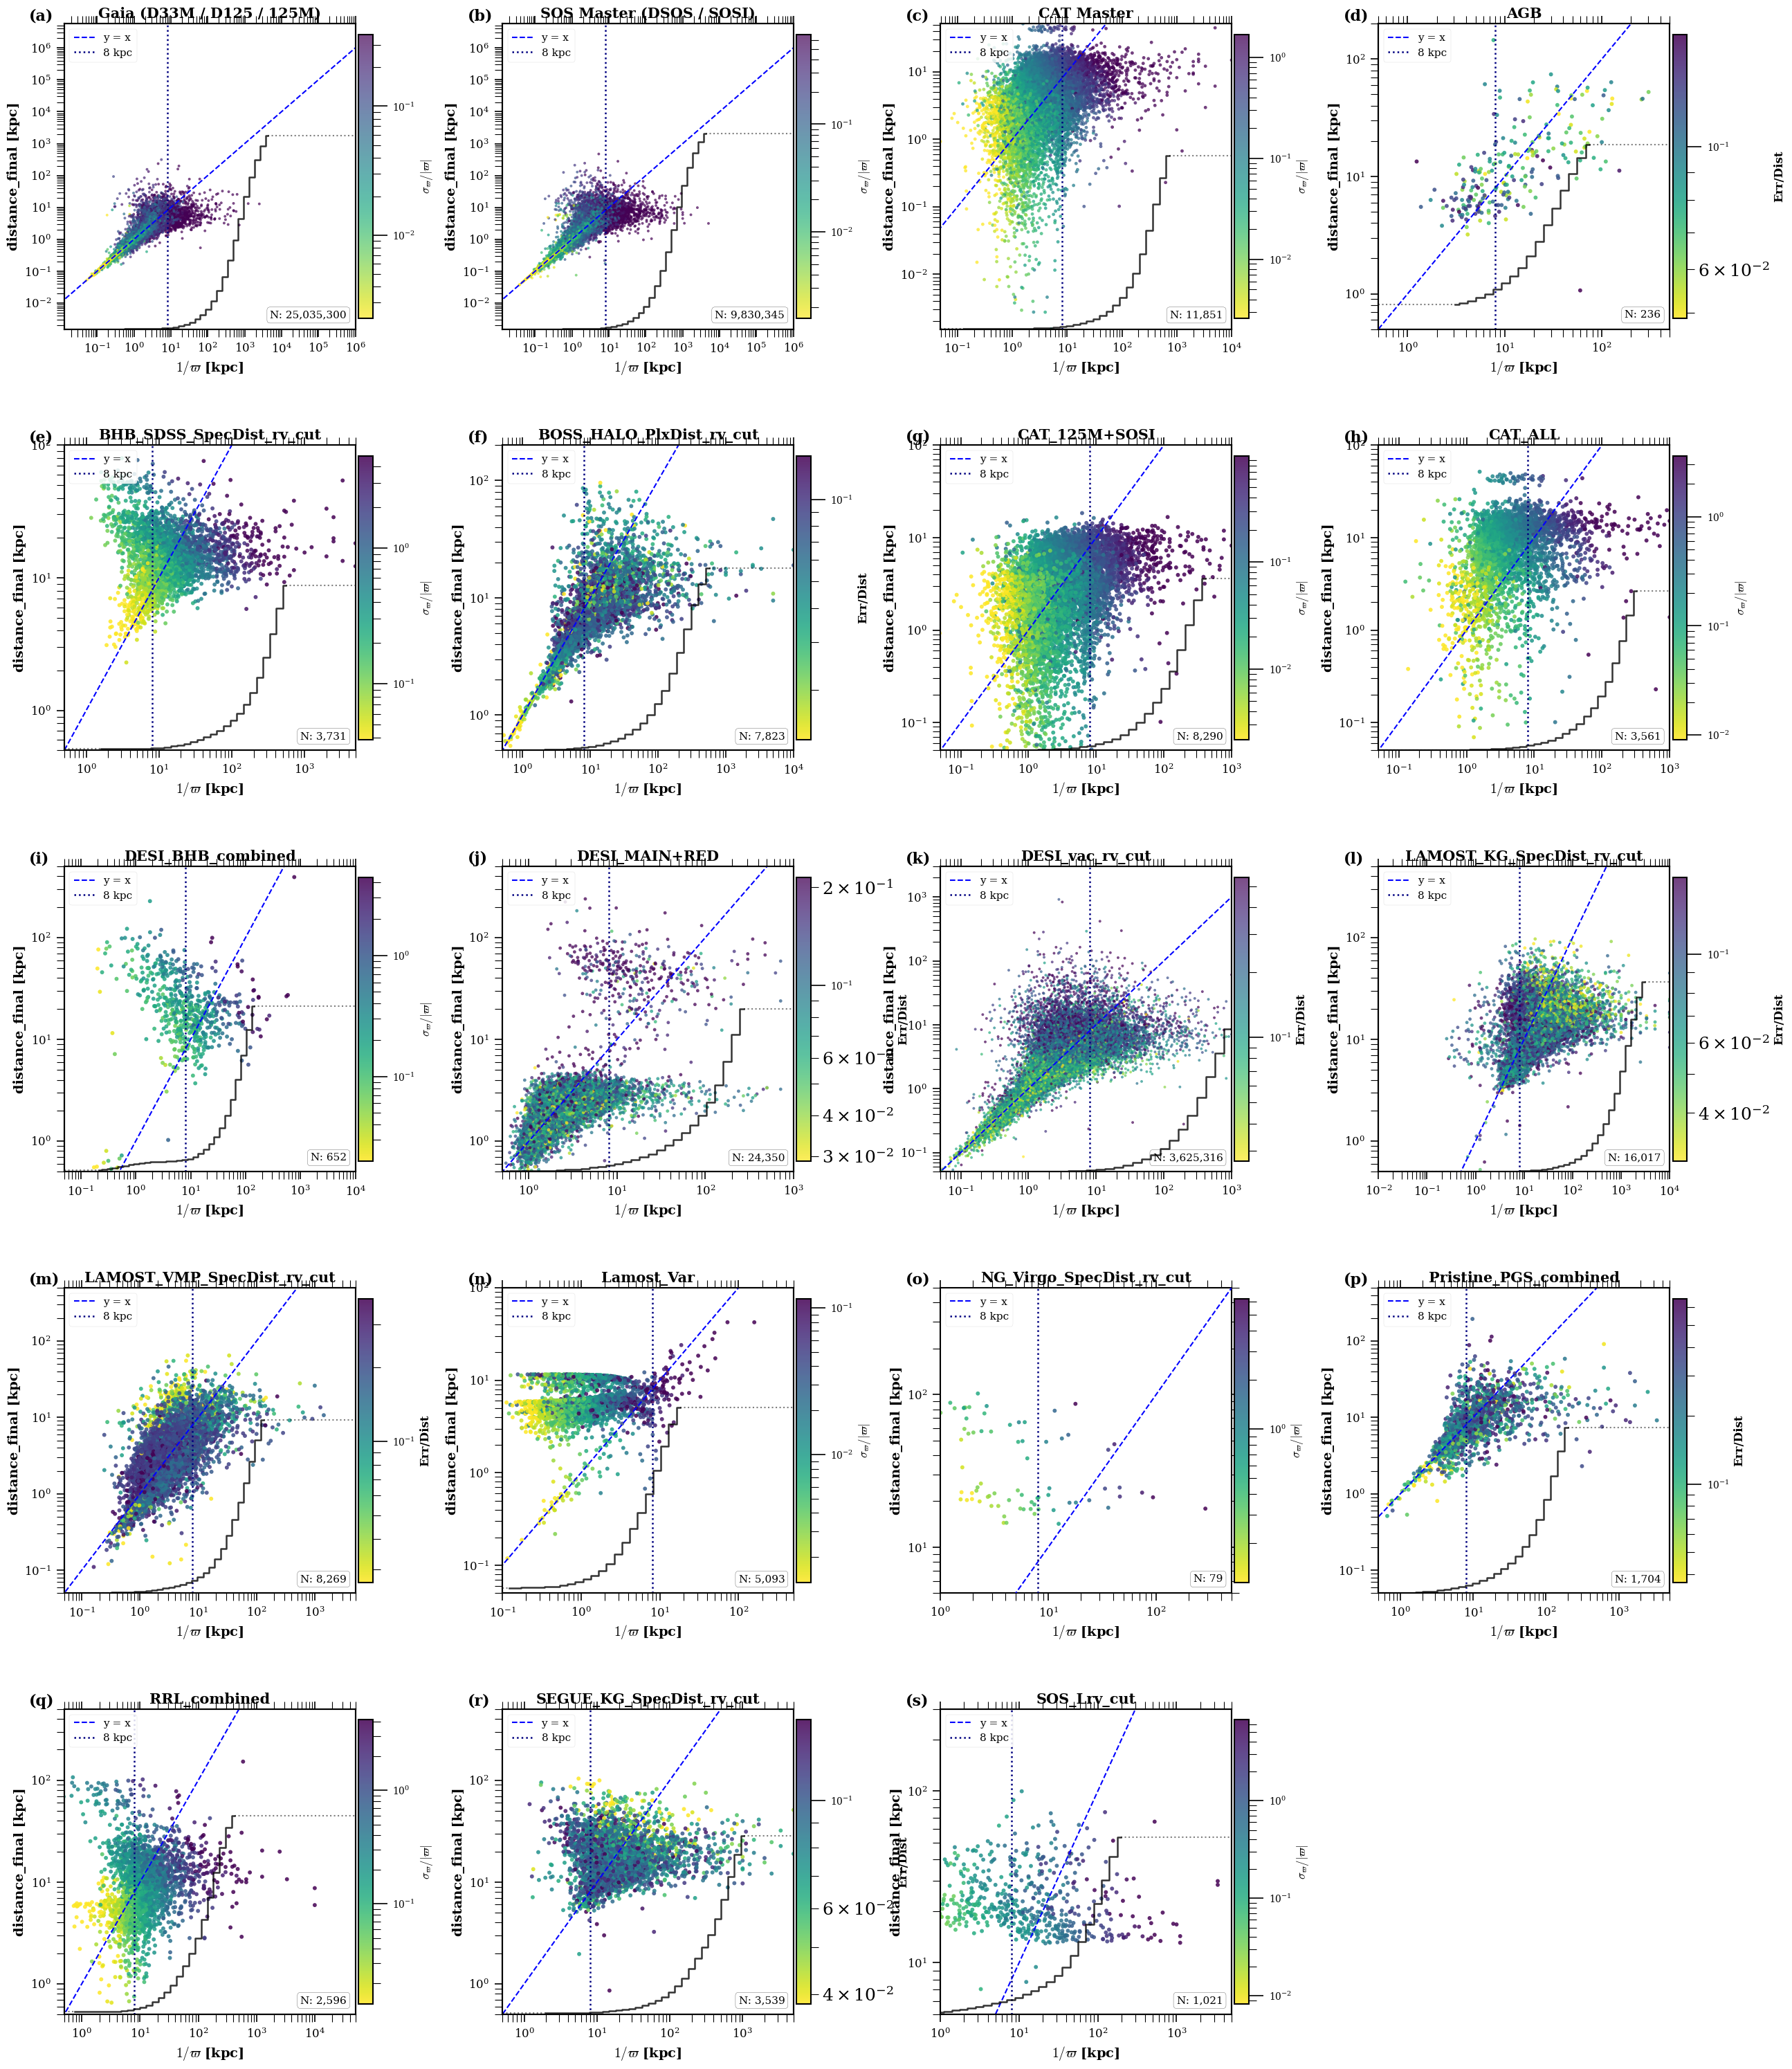

Done! PDF saved successfully.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter1d
from astropy.io import fits
import string
import warnings
from collections import defaultdict

warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
NUM_CHUNKS = 8
BASE_FILENAME = 'Entire_catalogue_chunk0'

# Surveys to combine (Old Rules)
COMBINE_SURVEYS = {
    'DESI_BHB_combined': ['DESI_BHB', 'BHB_DESI+LSDR9', 'DESI BHB', 'BHB DESI+LSDR9'],
    'RRL_combined': ['RRL', 'RRL PTR', 'RRL_PTR'],
    'Pristine_PGS_combined': ['PRISTINE+DESI_RGB', 'PGS+DESI_RGB']
}

# Create a reverse mapping for fast lookups
REVERSE_COMBINE = {}
for group_name, survey_list in COMBINE_SURVEYS.items():
    for survey in survey_list:
        REVERSE_COMBINE[survey] = group_name

# ============================================================
# SURVEY NAME MAP & CUSTOM RANGES
# ============================================================
SURVEY_NAME_MAP = {
    'AGB': 'AGB',
    'BHB_SDSS': 'BHB_SDSS_SpecDist_rv_cut',
    'BOSS_HALO': 'BOSS_HALO_PlxDist_rv_cut',
    'CAT_125M+SOSI': 'CAT_125M+SOSI',
    'CAT_ALL': 'CAT_ALL',
    'DESI_BHB_combined': 'DESI_BHB_combined',
    'DESI_MAIN+RED': 'DESI_MAIN+RED',
    'DESI_VAC_SPEC': 'DESI_vac_rv_cut',
    'LAMOST_KG': 'LAMOST_KG_SpecDist_rv_cut',
    'LAMOST_VMP': 'LAMOST_VMP_SpecDist_rv_cut',
    'Lamost_Var': 'Lamost_Var',
    'NG_Virgo': 'NG_Virgo_SpecDist_rv_cut',
    'Pristine_PGS_combined': 'Pristine_PGS_combined',
    'RRL_combined': 'RRL_combined',
    'SEGUE_KG': 'SEGUE_KG_SpecDist_rv_cut',
    'SOSI': 'SOS_Lrv_cut',
    'Gaia': 'Gaia (D33M / D125 / 125M)',
    'SOS': 'SOS Master (DSOS / SOSI)',
    'CAT': 'CAT Master'
}

CUSTOM_RANGES = {
    'AGB': {'x': (0.5, 500), 'y': (0.5, 200)},
    'BHB_SDSS': {'x': (0.5, 5000), 'y': (0.5, 100)},
    'BOSS_HALO': {'x': (0.5, 10000), 'y': (0.5, 200)},
    'CAT_125M+SOSI': {'x': (0.05, 1000), 'y': (0.05, 100)},
    'CAT_ALL': {'x': (0.05, 1000), 'y': (0.05, 100)},
    'DESI_BHB_combined': {'x': (0.05, 10000), 'y': (0.5, 500)},
    'DESI_MAIN+RED': {'x': (0.5, 1000), 'y': (0.5, 500)},
    'DESI_VAC_SPEC': {'x': (0.05, 1000), 'y': (0.05, 3000)},
    'LAMOST_KG': {'x': (0.01, 10000), 'y': (0.5, 500)},
    'LAMOST_VMP': {'x': (0.05, 5000), 'y': (0.05, 500)},
    'Lamost_Var': {'x': (0.1, 500), 'y': (0.05, 100)},
    'NG_Virgo': {'x': (1, 500), 'y': (5, 500)},
    'Pristine_PGS_combined': {'x': (0.5, 5000), 'y': (0.05, 500)},
    'RRL_combined': {'x': (0.5, 50000), 'y': (0.5, 500)},
    'SEGUE_KG': {'x': (0.5, 5000), 'y': (0.5, 500)},
    'SOSI': {'x': (1, 5000), 'y': (5, 300)},
}

CMAP = 'viridis_r'
REFERENCE_DIST_KPC = 8.0

# ============================================================
# PANEL ROUTING LOGIC
# ============================================================
def get_target_panels(survey_str, code_str):
    """Determines all panels a star belongs to based on the new overlapping rules."""
    panels = set()
    surveys = [s.strip() for s in str(survey_str).split(',') if s.strip()]
    codes = [c.strip() for c in str(code_str).split(',') if c.strip()]
    
    # 1. Gaia Rule: Any 33M or 125M in code, or 125M in survey
    if any(c in ['D33M', 'D125'] for c in codes) or any('125M' in s for s in surveys):
        panels.add('Gaia')
        
    # 2. SOS Rule: DSOS in code, or SOS in survey
    if any('DSOS' in c for c in codes) or any('SOS' in s for s in surveys):
        panels.add('SOS')
        
    # 3. CAT Rule: CAT in survey
    if any('CAT' in s for s in surveys):
        panels.add('CAT')
        
    # 4. Individual Surveys (Applying combine mappings)
    for s in surveys:
        mapped_s = REVERSE_COMBINE.get(s, s)
        panels.add(mapped_s)
        
    return list(panels)

# ============================================================
# DATA EXTRACTION LOOP
# ============================================================
print("Extracting and routing data across all chunks...")

# Master dictionary to hold arrays for each panel
panel_data = defaultdict(lambda: {'gaia_dist': [], 'DIST': [], 'rel_dist_err': [], 'rel_plx_err': []})

for i in range(NUM_CHUNKS):
    file_name = f"{BASE_FILENAME}{i+1}.fits"
    print(f" -> Processing {file_name}...")
    
    try:
        with fits.open(file_name, memmap=True) as hdul:
            data = hdul[1].data
            
            # Extract raw arrays using new column names
            dist = data['distance_final']
            dist_err = data['distance_err_final']
            plx = data['parallax_final']
            plx_err = data['parallax_err_final']
            surv_col = data['Survey_combined']
            code_col = data['Code_combined']
            
            # Calculate mathematical derivations
            gaia_dist = 1.0 / plx
            rel_dist_err = np.abs(dist_err / dist)
            rel_plx_err = np.abs(plx_err / plx)
            
            # Fast routing: Find unique combos of strings to avoid a 52-million row python loop
            combo_str = np.char.add(np.char.add(surv_col.astype(str), "|||"), code_col.astype(str))
            unique_combos, inverse_indices = np.unique(combo_str, return_inverse=True)
            
            for combo_idx, combo in enumerate(unique_combos):
                s_str, c_str = combo.split("|||")
                target_panels = get_target_panels(s_str, c_str)
                
                if not target_panels: continue
                
                # Get the mask for all rows that share this exact string combination
                mask = (inverse_indices == combo_idx)
                
                # Append the masked data to all target panels
                for p in target_panels:
                    panel_data[p]['gaia_dist'].append(gaia_dist[mask])
                    panel_data[p]['DIST'].append(dist[mask])
                    panel_data[p]['rel_dist_err'].append(rel_dist_err[mask])
                    panel_data[p]['rel_plx_err'].append(rel_plx_err[mask])
                    
            del data, dist, dist_err, plx, plx_err, surv_col, code_col
            
    except FileNotFoundError:
        print(f"    [!] Warning: {file_name} not found. Skipping.")

# Concatenate chunk lists into flat arrays for plotting
print("\nConcatenating arrays...")
final_panels = {}
for panel, arrays in panel_data.items():
    final_panels[panel] = {
        'gaia_dist': np.concatenate(arrays['gaia_dist']),
        'DIST': np.concatenate(arrays['DIST']),
        'rel_dist_err': np.concatenate(arrays['rel_dist_err']),
        'rel_plx_err': np.concatenate(arrays['rel_plx_err'])
    }
    print(f" - {panel}: {len(final_panels[panel]['DIST']):,} sources")


# ============================================================
# PLOTTING FUNCTION
# ============================================================
def plot_survey_panel(ax, data_dict, survey_name, cmap=CMAP, custom_ranges=None):
    x = data_dict['gaia_dist']
    y = data_dict['DIST']
    y_label = 'distance_final [kpc]'
    
    rel_err = data_dict['rel_dist_err']
    has_valid_disterr = np.sum(np.isfinite(rel_err)) > 0.5 * len(rel_err)
    
    if has_valid_disterr:
        color_values = rel_err
        color_label = 'Err/Dist'
    else:
        color_values = data_dict['rel_plx_err']
        color_label = r'$\sigma_\varpi / |\varpi|$'
    
    rel_plx_err = data_dict['rel_plx_err']
    
    # Valid data mask
    valid_mask = (np.isfinite(x) & np.isfinite(y) & np.isfinite(color_values) &
                  (x > 0) & (y > 0) & (color_values > 0))
    
    x_valid, y_valid = x[valid_mask], y[valid_mask]
    c_valid = color_values[valid_mask]
    rel_plx_valid = rel_plx_err[valid_mask]
    
    n_points = len(x_valid)
    
    if n_points == 0:
        ax.text(0.5, 0.5, 'No valid data', transform=ax.transAxes, ha='center', va='center', fontsize=14)
        ax.set_title(SURVEY_NAME_MAP.get(survey_name, survey_name), fontsize=15, fontweight='bold')
        return
    
    x_min, x_max = max(np.nanmin(x_valid), 0.001), np.nanmax(x_valid)
    y_min, y_max = max(np.nanmin(y_valid), 0.001), np.nanmax(y_valid)
    x_max, y_max = max(x_max, x_min * 10), max(y_max, y_min * 10)
    
    if custom_ranges and survey_name in custom_ranges:
        sr = custom_ranges[survey_name]
        if sr.get('x') is not None: x_min, x_max = sr['x']
        if sr.get('y') is not None: y_min, y_max = sr['y']
    
    c_min, c_max = max(np.nanpercentile(c_valid, 2), 0.001), np.nanpercentile(c_valid, 98)
    
    # Scatter sizing
    if n_points > 50000:
        idx = np.random.choice(n_points, size=50000, replace=False)
        x_plot, y_plot, c_plot = x_valid[idx], y_valid[idx], c_valid[idx]
        marker_size, alpha = 8, 0.7
    elif n_points > 10000:
        x_plot, y_plot, c_plot = x_valid, y_valid, c_valid
        marker_size, alpha = 12, 0.75
    else:
        x_plot, y_plot, c_plot = x_valid, y_valid, c_valid
        marker_size, alpha = 18, 0.85
    
    scatter = ax.scatter(x_plot, y_plot, c=c_plot, cmap=cmap, norm=LogNorm(vmin=c_min, vmax=c_max),
                         s=marker_size, alpha=alpha, edgecolors='none', rasterized=True)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    line_range = np.array([min(x_min, y_min) * 0.5, max(x_max, y_max) * 2])
    ax.plot(line_range, line_range, 'b--', lw=1.5, label='y = x', zorder=5)
    
    if x_min < REFERENCE_DIST_KPC < x_max * 1.5:
        ax.axvline(x=REFERENCE_DIST_KPC, color='navy', linestyle=':', lw=1.8, label='8 kpc', zorder=5)
    
    cbar = plt.colorbar(scatter, ax=ax, pad=0.01, fraction=0.046, aspect=20)
    cbar.set_label(color_label, fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)
    
    # --- Step Plot Logic ---
    step_mask = np.isfinite(x_valid) & np.isfinite(rel_plx_valid) & (rel_plx_valid > 0) & (rel_plx_valid < 100)
    x_step, err_step = x_valid[step_mask], rel_plx_valid[step_mask]
    
    if len(x_step) > 100:
        bins = np.logspace(np.log10(max(0.001, np.nanmin(x_step))), np.log10(np.nanmax(x_step)), 41)
        bin_centers = np.sqrt(bins[:-1] * bins[1:])
        bin_indices = np.digitize(x_step, bins)
        mean_err = np.array([np.nanmean(np.abs(err_step[bin_indices == i])) if np.sum(bin_indices == i) > 5 else np.nan for i in range(1, 41)])
        
        valid_bins = np.isfinite(mean_err) & (mean_err > 0)
        if np.sum(valid_bins) > 5:
            mean_err_interp = np.interp(np.arange(40), np.arange(40)[valid_bins], mean_err[valid_bins])
            mean_err_smooth = gaussian_filter1d(mean_err_interp, sigma=2)
            
            ax_step = ax.twinx()
            err_norm = mean_err_smooth / np.nanmax(mean_err_smooth)
            first_idx, last_idx = np.where(valid_bins)[0][0], np.where(valid_bins)[0][-1]
            
            ax_step.step(bin_centers[first_idx:last_idx+1], err_norm[first_idx:last_idx+1], where='mid', color='black', lw=1.8, alpha=0.8)
            
            if bin_centers[first_idx] > x_min:
                ax_step.step(np.logspace(np.log10(x_min), np.log10(bin_centers[first_idx]), 5), np.full(5, err_norm[first_idx]), where='mid', color='black', lw=1.5, alpha=0.5, linestyle=':')
            if bin_centers[last_idx] < x_max:
                ax_step.step(np.logspace(np.log10(bin_centers[last_idx]), np.log10(x_max), 5), np.full(5, err_norm[last_idx]), where='mid', color='black', lw=1.5, alpha=0.5, linestyle=':')
            
            ax_step.set_xscale('log')
            ax_step.set_ylim(0, 1.5)
            ax_step.set_yticks([])
            ax_step.set_xlim(ax.get_xlim())
    
    ax.set_xlabel(r'$1/\varpi$ [kpc]', fontsize=14, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=12, length=8, width=1.2)
    ax.legend(loc='upper left', fontsize=11, framealpha=0.85)
    ax.set_title(SURVEY_NAME_MAP.get(survey_name, survey_name), fontsize=15, fontweight='bold')
    ax.text(0.97, 0.03, f"N: {n_points:,}", transform=ax.transAxes, fontsize=11, ha='right', va='bottom', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# ============================================================
# CREATE PANEL PLOT
# ============================================================
print("\nCreating final panel plot...")

# Sort the panels so they appear in a consistent order (Gaia, SOS, CAT first, then alphabetical)
priority_panels = ['Gaia', 'SOS', 'CAT']
other_panels = sorted([p for p in final_panels.keys() if p not in priority_panels])
surveys_to_plot = priority_panels + other_panels
n_surveys = len(surveys_to_plot)

n_cols = min(4, n_surveys)
n_rows = int(np.ceil(n_surveys / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 6 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, survey in enumerate(surveys_to_plot):
    print(f"  Plotting {survey} ({idx+1}/{n_surveys})...")
    plot_survey_panel(axes[idx], final_panels[survey], survey, custom_ranges=CUSTOM_RANGES)

for idx in range(n_surveys, len(axes)):
    axes[idx].axis('off')

for idx, survey in enumerate(surveys_to_plot):
    label = f"({string.ascii_lowercase[idx]})"
    axes[idx].text(-0.12, 1.05, label, transform=axes[idx].transAxes, fontsize=16, fontweight='bold', va='top')

plt.tight_layout()
plt.subplots_adjust(hspace=0.38, wspace=0.42)

output_filename = 'fits_multi_survey_panel.pdf'
plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white', format='pdf')
plt.show()
print("Done! PDF saved successfully.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import warnings

# ==========================================
# PUBLICATION STYLE
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Times'],
    'mathtext.fontset': 'cm',
    'axes.labelsize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 12,
    'axes.unicode_minus': False,
    'xtick.major.size': 15, 'xtick.minor.size': 8,
    'ytick.major.size': 15, 'ytick.minor.size': 8,
    'xtick.major.width': 1.2, 'xtick.minor.width': 0.8,
    'ytick.major.width': 1.2, 'ytick.minor.width': 0.8,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'axes.linewidth': 1.5,
})

# ==========================================
# PART 1: PROCESS CATALOG 1 (Pre-merge)
# ==========================================
print("--- Processing Catalog 1 (Single File — Pre-merge) ---")
file_path_1 = 'Final_weight_cal_gaia_params_duplicate.fits'
rv_error_columns = [
    'radial_velocity_error_1', 'radial_velocity_error_2',
    'dr2_radial_velocity_error', 'VRAD_ERR', 'e_RV'
]
zp_column = 'e_ZP'

with fits.open(file_path_1, memmap=True) as hdul:
    data1 = hdul[1].data
    stacked_rv_errors = np.column_stack([data1[col] for col in rv_error_columns])
    e_zp_data = data1[zp_column]
    del data1

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    unique_rv_errors = np.nanmin(stacked_rv_errors, axis=1)

valid_mask_1 = ~np.isnan(unique_rv_errors)
aligned_rv_1 = unique_rv_errors[valid_mask_1]
aligned_zp_1 = e_zp_data[valid_mask_1]
aligned_zp_1 = np.nan_to_num(aligned_zp_1, nan=0.0)
combined_error_1 = np.sqrt(aligned_rv_1**2 + aligned_zp_1**2)

range_mask_1 = (combined_error_1 >= 0) & (combined_error_1 <= 20)
final_rv_1 = aligned_rv_1[range_mask_1]
final_zp_1 = aligned_zp_1[range_mask_1]
final_combined_1 = combined_error_1[range_mask_1]
print(f"Catalog 1 valid sources (0-20 km/s): {len(final_combined_1):,}\n")

# ==========================================
# PART 2: PROCESS CATALOG 2 (Post-merge)
# ==========================================
print("--- Processing Catalog 2 (8 Chunks — Post-merge) ---")
num_chunks = 8
base_filename = 'Entire_catalogue_chunk0'

all_combined_2, all_rv_2, all_zp_2, all_wt_avg_2 = [], [], [], []

for i in range(num_chunks):
    file_name = f"{base_filename}{i+1}.fits"
    print(f" -> Reading {file_name}...")
    try:
        with fits.open(file_name, memmap=True) as hdul:
            data2 = hdul[1].data
            rv_err_2 = data2['RV_err_final']
            zp_err_2 = data2['ZP_err_final']
            wt_avg_err_2 = data2['Weighted_Avg_err_final']

            valid_mask_2 = ~np.isnan(rv_err_2)
            aligned_rv_2 = rv_err_2[valid_mask_2]
            aligned_zp_2 = zp_err_2[valid_mask_2]
            aligned_zp_2 = np.nan_to_num(aligned_zp_2, nan=0.0)
            combined_2 = np.sqrt(aligned_rv_2**2 + aligned_zp_2**2)

            range_mask_2 = (combined_2 >= 0) & (combined_2 <= 20)
            all_combined_2.append(combined_2[range_mask_2])
            all_rv_2.append(aligned_rv_2[range_mask_2])
            all_zp_2.append(aligned_zp_2[range_mask_2])

            valid_mask_wt_2 = ~np.isnan(wt_avg_err_2)
            valid_wt_avg_2 = wt_avg_err_2[valid_mask_wt_2]
            all_wt_avg_2.append(valid_wt_avg_2[(valid_wt_avg_2 >= 0) & (valid_wt_avg_2 <= 20)])
            del data2, rv_err_2, zp_err_2, wt_avg_err_2
    except FileNotFoundError:
        print(f"    [!] Warning: {file_name} not found. Skipping.")

final_combined_2 = np.concatenate(all_combined_2)
final_rv_2 = np.concatenate(all_rv_2)
final_zp_2 = np.concatenate(all_zp_2)
final_wt_avg_2 = np.concatenate(all_wt_avg_2)
print(f"Catalog 2 total sources (0-20 km/s): {len(final_combined_2):,}\n")

# ==========================================
# PART 3: MASTER PLOT + INSET
# ==========================================
# COLOR SCHEME:
#   Main plot:
#     Cat 1 Combined (pre-merge)  → DOTTED opaque RED
#     Cat 2 Combined (post-merge) → SOLID RED
#     Cat 2 Weighted Average      → SOLID BLUE
#   Inset:
#     Cat 1 Raw RV (pre-merge)    → SOLID RED
#     Cat 2 Raw RV (post-merge)   → DOTTED RED
#     Cat 1 ZP (pre-merge)        → SOLID BLUE
#     Cat 2 ZP (post-merge)       → DOTTED BLUE
# ==========================================
print("Generating plot with inset...")
fig, ax = plt.subplots(figsize=(14, 8))

hist_kw = dict(bins=400, range=(0, 10), histtype='step', density=True)

# --- MAIN PLOT ---
ax.hist(final_combined_1, **hist_kw,
        color='#c62828', linewidth=2.5, linestyle=':',  alpha=0.85,
        label='Pre-merge: Combined RV+ZP Error')

ax.hist(final_combined_2, **hist_kw,
        color='#b71c1c', linewidth=2.5, linestyle='-', alpha=0.95,
        label='Post-merge: Combined RV+ZP Error')

ax.hist(final_wt_avg_2, **hist_kw,
        color='#1565c0', linewidth=2.5, linestyle='-',
        label='Post-merge: Weighted Avg Error')

ax.set_xlabel('Error Value (km/s)', fontsize=22, fontweight='bold')
ax.set_ylabel('Density (Normalized)', fontsize=22, fontweight='bold')
ax.set_xlim(0, 10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(fontsize=13, loc='upper left', framealpha=0.0, edgecolor='none')

# --- INSET PLOT: Raw Components ---
axins = ax.inset_axes([0.55, 0.45, 0.42, 0.45])
inset_kw = dict(bins=400, range=(0, 10), histtype='step', density=True)

# Raw RV errors
axins.hist(final_rv_1, **inset_kw,
           color='#c62828', linewidth=1.5, linestyle='-',
           label='Pre-merge: Raw RV')
axins.hist(final_rv_2, **inset_kw,
           color='#c62828', linewidth=1.5, linestyle=':',
           label='Post-merge: Raw RV')

# ZP errors (filter out zeros)
inset_zp_1 = final_zp_1[final_zp_1 > 0.0]
inset_zp_2 = final_zp_2[final_zp_2 > 0.0]

axins.hist(inset_zp_1, **inset_kw,
           color='#1565c0', linewidth=1.5, linestyle='-',
           label='Pre-merge: ZP Error')
axins.hist(inset_zp_2, **inset_kw,
           color='#1565c0', linewidth=1.5, linestyle=':',
           label='Post-merge: ZP Error')

axins.set_title('Component Errors (Raw RV & ZP, Non-Zero)', fontsize=11)
axins.set_xlim(0, 10)
axins.grid(axis='y', alpha=0.3, linestyle=':')
axins.legend(fontsize=8, loc='upper right', framealpha=0.0, edgecolor='none')

plt.tight_layout()
plot_filename = 'master_plot_with_inset_no_zeroes.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Success! Master plot saved as '{plot_filename}'")
plt.show()


In [ ]:
import os
import csv
import hashlib
import numpy as np
import h5py
import astropy.io.fits as pyfits
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import requests
import re
from pathlib import Path

# =============================================================================
# PUBLICATION STYLE
# =============================================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Times'],
    'mathtext.fontset': 'cm',
    'axes.labelsize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 10,
    'axes.unicode_minus': False,
    'xtick.major.size': 15, 'xtick.minor.size': 8,
    'ytick.major.size': 15, 'ytick.minor.size': 8,
    'xtick.major.width': 1.2, 'xtick.minor.width': 0.8,
    'ytick.major.width': 1.2, 'ytick.minor.width': 0.8,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'axes.linewidth': 1.5,
})

# =============================================================================
# COLOR SCHEME — Strictly matching the distance-error reference image
# =============================================================================
viridis = cm.viridis

# --- Image-matched colors ---
COLOR_33M       = viridis(0.85)       # Yellow-green, dash-dot
COLOR_125M      = viridis(0.65)       # Green-teal (between 33M and 17M)
COLOR_OTHERS    = '#a8a8a8'           # Light gray, dashed
COLOR_DESI_DARK = '#1a1a1a'           # Near-black, solid
COLOR_DESI_BRT  = '#3d3d3d'           # Dark gray, solid
COLOR_DESI_BKP  = '#636363'           # Medium gray, solid

# --- Vibrant additions for surveys not in image ---
COLOR_SOS       = '#00acc1'           # Cyan/teal, dashed
COLOR_LAMOST    = '#e65100'           # Vibrant orange, solid
COLOR_SDSS      = '#d81b60'           # Vibrant magenta, dash-dot

# =============================================================================
# PATHS
# =============================================================================
CACHE_DIR = '../query_cache/'
DATA_PATH = './data/'
MAIN_FILE = 'mwsall-pix-iron.fits'
FNAME = os.path.join(DATA_PATH, MAIN_FILE)

# Path to pre-binned CSV (from lower cell)
CSV_DIR = Path('/user/sutirtha/BallTree_Xmatch')
GMAG_CSV = CSV_DIR / 'plot_Gmag_data.csv'

# =============================================================================
# CACHE HELPERS (from original Cell 6)
# =============================================================================
def _hash_query(query, kwargs):
    hasher = hashlib.sha256()
    hasher.update(query.encode("utf-8"))
    as_dict_val = kwargs.get("asDict", False)
    hasher.update(f"asDict={as_dict_val}".encode("utf-8"))
    return hasher.hexdigest()

def _load_hdf5(filename):
    with h5py.File(filename, 'r') as f:
        is_dict = bool(f.attrs['IS_DICT'])
        if is_dict:
            return {k: np.array(f[k]) for k in f.keys()}
        num_arrays = f.attrs['NUM_ARRAYS']
        return tuple(np.array(f[f"arr_{i}"]) for i in range(num_arrays))

def get_cached_data(query, **kwargs):
    query_hash = _hash_query(query, kwargs)
    cache_file = os.path.join(CACHE_DIR, f"{query_hash}.hdf5")
    if os.path.isfile(cache_file):
        print(f"Loading from cache: {cache_file}")
        return _load_hdf5(cache_file)
    raise FileNotFoundError(f"Cache miss! Could not find {cache_file}.")

# =============================================================================
# CSV READER (from original Cell 9)
# =============================================================================
def read_binned_histogram(csv_path):
    """Reads pre-binned CSV and returns dict of {SurveyName: (bins, counts)}."""
    surveys = {}
    if not csv_path.exists():
        print(f"Warning: CSV not found: {csv_path}")
        return surveys
    with csv_path.open(newline="", encoding="utf-8") as handle:
        reader = csv.DictReader(handle)
        fieldnames = [name.strip() for name in reader.fieldnames]
        rows = list(reader)
        for bin_col in fieldnames:
            if not bin_col.endswith("_Bin"):
                continue
            survey_name = bin_col[: -len("_Bin")]
            count_col = f"{survey_name}_Counts"
            if count_col not in fieldnames:
                continue
            bins, counts = [], []
            for row in rows:
                raw_bin = (row.get(bin_col) or "").strip()
                raw_count = (row.get(count_col) or "").strip()
                if not raw_bin or not raw_count:
                    continue
                try:
                    bins.append(float(raw_bin))
                    counts.append(float(raw_count))
                except ValueError:
                    continue
            if not bins:
                continue
            b = np.asarray(bins); c = np.asarray(counts)
            order = np.argsort(b)
            surveys[survey_name] = (b[order], c[order])
    return surveys

# =============================================================================
# PART A: Load raw data from FITS / Cache (from original Cell 6)
# =============================================================================
print("=" * 60)
print("COMBINED G-mag DISTRIBUTION")
print("=" * 60)

print("Loading DESI FITS data...")
T = pyfits.getdata(FNAME, 'RVTAB')
GT = pyfits.getdata(FNAME, 'GAIA')

print("Fetching LAMOST & SDSS from cache...")
lam_query = 'select gaia_g_mean_mag from lamost_dr9.lrs_stellar'
sdss_query = """select  phot_g_mean_mag from gaia_dr3.gaia_source as g ,
gaia_edr3_aux.sdssdr13bestneighbour as x,
sdssdr14.sppparams as sp, sdssdr14.specphotoall as s
where x.original_ext_source_id =s.objid and
    g.source_id=x.source_id and (elodiervfinal between -1000 and 1000) and
s.scienceprimary=1 and
s.specobjid=sp.specobjid and fehadop > -6 and fehadop <10 ;"""

lam_t = get_cached_data(lam_query)[0]
sdss_t = get_cached_data(sdss_query)[0]

# Load SOS DR1
print("Streaming SOS DR1 from Google Drive...")
file_id = '152Xos4tk5uzvBMC1oAGH6ppnLpgTjlmV'
url = f"https://drive.google.com/uc?export=download&id={file_id}"
session = requests.Session()
response = session.get(url)

if "Virus scan warning" in response.text:
    confirm_token = re.search(r'name="confirm" value="([^"]+)"', response.text).group(1)
    uuid_match = re.search(r'name="uuid" value="([^"]+)"', response.text)
    uuid_token = uuid_match.group(1) if uuid_match else ""
    download_url = "https://drive.usercontent.google.com/download"
    params = {'id': file_id, 'export': 'download', 'confirm': confirm_token, 'uuid': uuid_token}
    response = session.get(download_url, params=params, stream=True)
else:
    response = session.get(url, stream=True)

response.raw.decode_content = True
df_sos = pd.read_csv(response.raw, usecols=['sosdr1_photGMeanMag'], engine='c')
sos_t = df_sos['sosdr1_photGMeanMag'].dropna().values

# =============================================================================
# PART B: Load pre-binned CSV data
# =============================================================================
print("Loading pre-binned CSV data...")
csv_surveys = read_binned_histogram(GMAG_CSV)
print(f"  Surveys found in CSV: {list(csv_surveys.keys())}")

# Identify CSV surveys by keyword matching
def find_csv_survey(csv_surveys, keywords, exclude_keywords=None):
    """Find a survey in CSV dict by keyword matching (case-insensitive)."""
    for name in csv_surveys:
        name_up = name.upper()
        if all(kw.upper() in name_up for kw in keywords):
            if exclude_keywords and any(ek.upper() in name_up for ek in exclude_keywords):
                continue
            return name
    return None

csv_33m_key   = find_csv_survey(csv_surveys, ['33M'], exclude_keywords=['125'])
csv_125m_key  = find_csv_survey(csv_surveys, ['125M'])
csv_other_key = find_csv_survey(csv_surveys, ['OTHER'])
csv_lam_key   = find_csv_survey(csv_surveys, ['LAMOST'])
csv_sdss_key  = find_csv_survey(csv_surveys, ['SDSS'])

print(f"  Matched CSV keys: 33M={csv_33m_key}, 125M={csv_125m_key}, "
      f"Others={csv_other_key}, LAMOST={csv_lam_key}, SDSS={csv_sdss_key}")

# =============================================================================
# PART C: Merge LAMOST & SDSS from raw + CSV
# =============================================================================
# Strategy: bin the raw data from Cell 6 onto the same bin grid as the CSV,
# then add the counts together.

min_mag, max_mag = 10, 22
n_bins = int((max_mag - min_mag) * 10)  # 0.1 mag bins

def merge_raw_and_csv(raw_data, csv_key, csv_surveys, n_bins, mag_range):
    """Bin raw data, add CSV counts if available, return (edges, merged_counts)."""
    raw_counts, edges = np.histogram(raw_data, bins=n_bins, range=mag_range)
    centers = 0.5 * (edges[:-1] + edges[1:])
    merged = raw_counts.astype(float).copy()

    if csv_key and csv_key in csv_surveys:
        csv_bins, csv_counts = csv_surveys[csv_key]
        # Interpolate CSV counts onto our bin grid and add
        from scipy.interpolate import interp1d
        f = interp1d(csv_bins, csv_counts, kind='nearest',
                     bounds_error=False, fill_value=0)
        merged += f(centers)
        print(f"  Merged raw ({len(raw_data):,}) + CSV '{csv_key}' counts")
    else:
        print(f"  Using raw data only ({len(raw_data):,})")

    return edges, merged

print("\nMerging LAMOST...")
lam_edges, lam_merged = merge_raw_and_csv(lam_t, csv_lam_key, csv_surveys,
                                           n_bins, (min_mag, max_mag))

print("Merging SDSS...")
sdss_edges, sdss_merged = merge_raw_and_csv(sdss_t, csv_sdss_key, csv_surveys,
                                             n_bins, (min_mag, max_mag))

# =============================================================================
# PART D: Collect any unique surveys from CSV not yet covered
# =============================================================================
# Already handled: 33M, 125M, Others, LAMOST, SDSS
# Explicitly skip: any DESI or SOS entries from CSV
handled_csv_keys = {csv_33m_key, csv_125m_key, csv_other_key, csv_lam_key, csv_sdss_key}
extra_csv = {}
for name, (b, c) in csv_surveys.items():
    if name in handled_csv_keys:
        continue
    name_up = name.upper()
    # Skip DESI and SOS from CSV
    if 'DESI' in name_up or 'SOS' in name_up:
        continue
    extra_csv[name] = (b, c)

if extra_csv:
    print(f"\nExtra unique CSV surveys to include: {list(extra_csv.keys())}")

# =============================================================================
# PART E: PLOTTING
# =============================================================================
print("\nGenerating combined G-mag plot...")
fig, ax = plt.subplots(figsize=(12, 7))

hist_kw = dict(histtype='step', range=[min_mag, max_mag], bins=n_bins, linewidth=2.0)
shift = 1 / 9.  # tiny bin-shift to avoid perfect overlap

# --- DESI programs (from FITS) ---
for prog, col, ls in [('dark', COLOR_DESI_DARK, '-'),
                       ('bright', COLOR_DESI_BRT, '-'),
                       ('backup', COLOR_DESI_BKP, '-')]:
    sub = ((T['RVS_WARN'] == 0) & (T['RR_SPECTYPE'] == 'STAR') &
           (T['PRIMARY']) & (T['SURVEY'] == 'main') & (T['PROGRAM'] == prog))
    ax.hist(GT['PHOT_G_MEAN_MAG'][sub], color=col, label=f'DESI DR1 {prog}',
            linestyle=ls, **hist_kw)
    hist_kw['range'] = [hist_kw['range'][0] + shift, hist_kw['range'][1] + shift]

# --- SOS DR1 (from FITS/GDrive) ---
ax.hist(sos_t, color=COLOR_SOS, label='SOS DR1', linestyle='--', **hist_kw)
hist_kw['range'] = [hist_kw['range'][0] + shift, hist_kw['range'][1] + shift]

# --- 33M (from CSV) ---
if csv_33m_key and csv_33m_key in csv_surveys:
    b33, c33 = csv_surveys[csv_33m_key]
    w33 = np.median(np.diff(b33)) if len(b33) > 1 else 0.1
    edges33 = np.append(b33 - w33/2, b33[-1] + w33/2)
    step33 = np.append(c33, c33[-1])
    ax.step(edges33, step33, where='post', color=COLOR_33M, linestyle='-.',
            linewidth=2.5, label='Gaia DR3 33M RVS')

# --- 125M (from CSV) ---
if csv_125m_key and csv_125m_key in csv_surveys:
    b125, c125 = csv_surveys[csv_125m_key]
    w125 = np.median(np.diff(b125)) if len(b125) > 1 else 0.1
    edges125 = np.append(b125 - w125/2, b125[-1] + w125/2)
    step125 = np.append(c125, c125[-1])
    ax.step(edges125, step125, where='post', color=COLOR_125M, linestyle='-',
            linewidth=2.5, label='Gaia 125M')

# --- Others (from CSV) ---
if csv_other_key and csv_other_key in csv_surveys:
    bo, co = csv_surveys[csv_other_key]
    wo = np.median(np.diff(bo)) if len(bo) > 1 else 0.1
    edgeso = np.append(bo - wo/2, bo[-1] + wo/2)
    stepo = np.append(co, co[-1])
    ax.step(edgeso, stepo, where='post', color=COLOR_OTHERS, linestyle='--',
            linewidth=2.0, label='OTHERS')

# --- LAMOST (merged raw + CSV) ---
step_lam = np.append(lam_merged, lam_merged[-1])
ax.step(lam_edges, step_lam, where='post', color=COLOR_LAMOST,
        linestyle='-', linewidth=2.5, label='LAMOST (merged)')

# --- SDSS (merged raw + CSV) ---
step_sdss = np.append(sdss_merged, sdss_merged[-1])
ax.step(sdss_edges, step_sdss, where='post', color=COLOR_SDSS,
        linestyle='-.', linewidth=2.5, label='SDSS (merged)')

# --- Extra unique CSV surveys ---
extra_colors = ['#7b1fa2', '#0097a7', '#558b2f', '#f57f17']
extra_ls = ['--', ':', '-.', '-']
for idx, (name, (b, c)) in enumerate(extra_csv.items()):
    w = np.median(np.diff(b)) if len(b) > 1 else 0.1
    e = np.append(b - w/2, b[-1] + w/2)
    s = np.append(c, c[-1])
    ax.step(e, s, where='post',
            color=extra_colors[idx % len(extra_colors)],
            linestyle=extra_ls[idx % len(extra_ls)],
            linewidth=2.0, label=name)

# --- Formatting ---
ax.set_xlim(11, 21)
ax.set_ylim(10, None)
ax.set_yscale('log')
ax.set_xlabel(r'$G$ [mag]')
ax.set_ylabel(r'$\mathrm{N_{stars}/bin}$')
ax.legend(loc='upper left', frameon=False, fontsize=12, ncol=2)

plt.tight_layout()
os.makedirs('plots', exist_ok=True)
save_path = 'plots/combined_gmag_distribution.pdf'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Plot saved to {save_path}")
plt.show()


In [ ]:
import os
import csv
import hashlib
import numpy as np
import h5py
import astropy.table as atpy
import astropy.units as auni
import astropy.coordinates as acoo
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

# =============================================================================
# PUBLICATION STYLE
# =============================================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Times'],
    'mathtext.fontset': 'cm',
    'axes.labelsize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 10,
    'axes.unicode_minus': False,
    'xtick.major.size': 15, 'xtick.minor.size': 8,
    'ytick.major.size': 15, 'ytick.minor.size': 8,
    'xtick.major.width': 1.2, 'xtick.minor.width': 0.8,
    'ytick.major.width': 1.2, 'ytick.minor.width': 0.8,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'axes.linewidth': 1.5,
})

# =============================================================================
# COLOR SCHEME — Matching the distance-error reference image palette
# =============================================================================
viridis = cm.viridis

# Surveys from FITS (Cell 8 upper)
COLOR_DESI_RVS  = '#1a1a1a'           # Near-black (DESI-like)
COLOR_DESI_SP   = '#3d3d3d'           # Dark gray
COLOR_GALAH     = '#00acc1'           # Cyan/teal
COLOR_APOGEE    = '#e65100'           # Vibrant orange
COLOR_GAIA_DR3  = viridis(0.85)       # Yellow-green
COLOR_SAGA      = '#d81b60'           # Vibrant magenta

# Surveys from CSV that may be unique
COLOR_CSV_EXTRA = ['#7b1fa2', '#0097a7', '#558b2f', '#f57f17',
                   viridis(0.50), viridis(0.65)]

# =============================================================================
# PATHS
# =============================================================================
CACHE_DIR = '../query_cache/'
DATA_PATH = './data/'
EXT_PATH  = './external/'
MAIN_FILE = 'mwsall-pix-iron.fits'
FNAME = os.path.join(DATA_PATH, MAIN_FILE)

CSV_DIR  = Path('/user/sutirtha/BallTree_Xmatch')
FEH_CSV  = CSV_DIR / 'plot_FEH_data.csv'

# =============================================================================
# CACHE HELPERS
# =============================================================================
def _encode_for_hash(item):
    if isinstance(item, np.ndarray):
        return str(item.shape).encode('utf-8') + str(item.dtype).encode('utf-8') + item.tobytes()
    elif isinstance(item, (list, tuple)):
        return _encode_for_hash(np.array(item))
    return str(item).encode('utf-8')

def _hash_call(method_name, *args, **kwargs):
    hasher = hashlib.sha256()
    hasher.update(method_name.encode("utf-8"))
    for arg in args: hasher.update(_encode_for_hash(arg))
    for k in sorted(kwargs.keys()):
        hasher.update(k.encode("utf-8"))
        hasher.update(_encode_for_hash(kwargs[k]))
    return hasher.hexdigest()

def _load_hdf5(filename):
    with h5py.File(filename, 'r') as f:
        is_dict = bool(f.attrs['IS_DICT'])
        if is_dict:
            return {k: np.array(f[k]) for k in f.keys()}
        num_arrays = f.attrs['NUM_ARRAYS']
        return tuple(np.array(f[f"arr_{i}"]) for i in range(num_arrays))

def _find_cache_by_columns(columns):
    columns_string = ','.join(columns) if isinstance(columns, (list, tuple)) else columns
    unique_key = None
    if 'flag_fe_h' in columns_string: unique_key = 'flag_fe_h'
    elif 'aspcapflag' in columns_string: unique_key = 'aspcapflag'
    elif 'good_flag' in columns_string: unique_key = 'good_flag'
    for fname in os.listdir(CACHE_DIR):
        if fname.endswith('.hdf5'):
            filepath = os.path.join(CACHE_DIR, fname)
            try:
                with h5py.File(filepath, 'r') as f:
                    if bool(f.attrs.get('IS_DICT', 0)) and unique_key and unique_key in f.keys():
                        return filepath
            except Exception:
                continue
    return None

def doit_by_key(table, key_values, columns, **kwargs):
    if not os.path.exists(CACHE_DIR): os.makedirs(CACHE_DIR)
    call_hash = _hash_call("doit_by_key", table, key_values, columns, **kwargs)
    cache_file = os.path.join(CACHE_DIR, f"{call_hash}.hdf5")
    if os.path.isfile(cache_file):
        print(f"[CACHE HIT] Loaded {table} offline.")
        return _load_hdf5(cache_file)
    print(f"[CACHE RECOVERY] Searching for {table} cache by column signatures...")
    smart_file = _find_cache_by_columns(columns)
    if smart_file:
        print(f"[SMART CACHE HIT] Successfully recovered {table}!")
        return _load_hdf5(smart_file)
    raise FileNotFoundError(f"Cache miss for {table}.")

# =============================================================================
# SAGA HELPER
# =============================================================================
def get_saga(ra, dec):
    saga_file = os.path.join(EXT_PATH, 'saga_cleaned_catalog.tsv')
    if not os.path.exists(saga_file):
        print(f"Warning: SAGA catalog not found at {saga_file}. Skipping.")
        return {'fe_h': np.full(len(ra), np.nan, dtype=float)}
    SAGAT = atpy.Table().read(saga_file, format='ascii')
    c_input = acoo.SkyCoord(ra=ra * auni.deg, dec=dec * auni.deg)
    c_saga  = acoo.SkyCoord(ra=SAGAT['RAdeg'] * auni.deg, dec=SAGAT['DECdeg'] * auni.deg)
    idx, sep2d, _ = c_input.match_to_catalog_sky(c_saga)
    match_mask = (sep2d.arcsec < 1.0)
    SAGA_R = {'fe_h': np.full(len(ra), np.nan, dtype=float)}
    SAGA_R['fe_h'][match_mask] = SAGAT['[M/H]'].filled(np.nan)[idx][match_mask]
    return SAGA_R

# =============================================================================
# CSV READER
# =============================================================================
def read_binned_histogram(csv_path):
    surveys = {}
    if not csv_path.exists():
        print(f"Warning: CSV not found: {csv_path}")
        return surveys
    with csv_path.open(newline="", encoding="utf-8") as handle:
        reader = csv.DictReader(handle)
        fieldnames = [name.strip() for name in reader.fieldnames]
        rows = list(reader)
        for bin_col in fieldnames:
            if not bin_col.endswith("_Bin"):
                continue
            survey_name = bin_col[: -len("_Bin")]
            count_col = f"{survey_name}_Counts"
            if count_col not in fieldnames:
                continue
            bins, counts = [], []
            for row in rows:
                raw_bin = (row.get(bin_col) or "").strip()
                raw_count = (row.get(count_col) or "").strip()
                if not raw_bin or not raw_count:
                    continue
                try:
                    bins.append(float(raw_bin))
                    counts.append(float(raw_count))
                except ValueError:
                    continue
            if not bins:
                continue
            b = np.asarray(bins); c = np.asarray(counts)
            order = np.argsort(b)
            surveys[survey_name] = (b[order], c[order])
    return surveys

def find_csv_survey(csv_surveys, keywords, exclude_keywords=None):
    for name in csv_surveys:
        name_up = name.upper()
        if all(kw.upper() in name_up for kw in keywords):
            if exclude_keywords and any(ek.upper() in name_up for ek in exclude_keywords):
                continue
            return name
    return None

# =============================================================================
# PART A: Load DESI + external data (from original Cell 8)
# =============================================================================
print("=" * 60)
print("COMBINED [Fe/H] DISTRIBUTION")
print("=" * 60)

print("Loading DESI FITS data...")
RV_T = atpy.Table().read(FNAME, 'RVTAB', mask_invalid=False)
SP_T = atpy.Table().read(FNAME, 'SPTAB', mask_invalid=False)
G_T  = atpy.Table().read(FNAME, 'GAIA',  mask_invalid=False)

# Quality cuts
main_sel0 = (RV_T['RVS_WARN'] == 0) & (RV_T['RR_SPECTYPE'] == 'STAR')
main_sel  = main_sel0 & (RV_T['SURVEY'] == 'main') & (RV_T['SN_R'] > 10)
rv_sel    = main_sel & (RV_T['FEH_ERR'] < 0.1) & (RV_T['VSINI'] < 30)
sp_sel    = main_sel & ((SP_T['BESTGRID'] != 's_rdesi1') & (SP_T['COVAR'][:, 0, 0]**.5 < .1))

ra, dec = RV_T['TARGET_RA'], RV_T['TARGET_DEC']

print("Fetching External Surveys via Cache...")
D_SAGA = get_saga(ra, dec)
D_GA = doit_by_key('galah_dr4.allstar', G_T['SOURCE_ID'],
                    'fe_h,flag_fe_h,flag_sp', db='wsdb', asDict=True,
                    key_col='gaiadr3_source_id')
D_AP = doit_by_key('apogee_dr17.allstar', G_T['SOURCE_ID'],
                    'fe_h,aspcapflag,starflag,fe_h_flag',
                    key_col='gaiaedr3_source_id', db='wsdb', asDict=True)
D_GAIA = doit_by_key('gaia_dr3.astrophysical_parameters', G_T['SOURCE_ID'],
                      "mh_gspspec, coalesce(flags_gspspec like '0000000000000%', false) as good_flag",
                      key_col='source_id', db='wsdb', asDict=True)

# Clean external flags
D_GAIA['fe_h'] = np.where(D_GAIA['good_flag'], D_GAIA['mh_gspspec'], np.nan)
D_AP['fe_h'][(D_AP['fe_h_flag'] != 0) | (D_AP['starflag'] != 0) | (D_AP['aspcapflag'] != 0)] = np.nan
D_GA['fe_h'][(D_GA['flag_fe_h'] != 0) | (D_GA['flag_sp'] != 0)] = np.nan

galah_clean  = D_GA['fe_h'][np.isfinite(D_GA['fe_h'])]
apogee_clean = D_AP['fe_h'][np.isfinite(D_AP['fe_h'])]
gaia_clean   = D_GAIA['fe_h'][np.isfinite(D_GAIA['fe_h'])]
saga_clean   = D_SAGA['fe_h'][np.isfinite(D_SAGA['fe_h'])]

# =============================================================================
# PART B: Load pre-binned CSV
# =============================================================================
print("\nLoading pre-binned FeH CSV...")
csv_surveys = read_binned_histogram(FEH_CSV)
print(f"  Surveys found in CSV: {list(csv_surveys.keys())}")

# Skip DESI and SOS from CSV; identify unique extras
csv_handled = set()

# Check if any raw surveys also appear in CSV for merging
csv_galah_key  = find_csv_survey(csv_surveys, ['GALAH'])
csv_apogee_key = find_csv_survey(csv_surveys, ['APOGEE'])
csv_gaia_key   = find_csv_survey(csv_surveys, ['GAIA'], exclude_keywords=['33M', '125M', '220M'])
csv_saga_key   = find_csv_survey(csv_surveys, ['SAGA'])

for k in [csv_galah_key, csv_apogee_key, csv_gaia_key, csv_saga_key]:
    if k: csv_handled.add(k)

# =============================================================================
# PART C: Merge overlapping surveys
# =============================================================================
min_feh, max_feh = -3.5, 1.0
n_bins = int((max_feh - min_feh) * 20)  # 0.05 dex bins

def merge_raw_and_csv_feh(raw_data, csv_key, csv_surveys, n_bins, feh_range):
    raw_counts, edges = np.histogram(raw_data, bins=n_bins, range=feh_range)
    centers = 0.5 * (edges[:-1] + edges[1:])
    merged = raw_counts.astype(float).copy()
    if csv_key and csv_key in csv_surveys:
        csv_bins, csv_counts = csv_surveys[csv_key]
        from scipy.interpolate import interp1d
        f = interp1d(csv_bins, csv_counts, kind='nearest',
                     bounds_error=False, fill_value=0)
        merged += f(centers)
        print(f"  Merged raw ({len(raw_data):,}) + CSV '{csv_key}'")
    return edges, merged

# Merge each survey that appears in both
gal_edges, gal_merged = merge_raw_and_csv_feh(galah_clean, csv_galah_key,
                                                csv_surveys, n_bins,
                                                (min_feh, max_feh))
apo_edges, apo_merged = merge_raw_and_csv_feh(apogee_clean, csv_apogee_key,
                                                csv_surveys, n_bins,
                                                (min_feh, max_feh))
gia_edges, gia_merged = merge_raw_and_csv_feh(gaia_clean, csv_gaia_key,
                                                csv_surveys, n_bins,
                                                (min_feh, max_feh))
sag_edges, sag_merged = merge_raw_and_csv_feh(saga_clean, csv_saga_key,
                                                csv_surveys, n_bins,
                                                (min_feh, max_feh))

# Collect unique CSV-only surveys (skip DESI, SOS, and already-handled)
extra_csv = {}
for name, (b, c) in csv_surveys.items():
    if name in csv_handled:
        continue
    name_up = name.upper()
    if 'DESI' in name_up or 'SOS' in name_up:
        continue
    extra_csv[name] = (b, c)

if extra_csv:
    print(f"\nExtra unique CSV surveys: {list(extra_csv.keys())}")

# =============================================================================
# PART D: PLOTTING
# =============================================================================
print("\nGenerating combined [Fe/H] plot...")
fig, ax = plt.subplots(figsize=(12, 7))

hist_kw = dict(histtype='step', range=[min_feh, max_feh], bins=n_bins, linewidth=2.5)

# DESI (raw histograms, no CSV merge needed — already skipping CSV DESI)
ax.hist(RV_T['FEH'][rv_sel], color=COLOR_DESI_RVS, label='DESI DR1 RVS', **hist_kw)
ax.hist(SP_T['FEH'][sp_sel], color=COLOR_DESI_SP, label='DESI DR1 SP',
        linestyle='--', **hist_kw)

# Merged surveys (step plots from merged counts)
def plot_merged(edges, counts, color, label, ls='-', lw=2.5):
    step_c = np.append(counts, counts[-1])
    ax.step(edges, step_c, where='post', color=color, linestyle=ls,
            linewidth=lw, label=label)

if len(galah_clean) > 0:
    plot_merged(gal_edges, gal_merged, COLOR_GALAH, 'GALAH DR4 (merged)', ls='--')
if len(apogee_clean) > 0:
    plot_merged(apo_edges, apo_merged, COLOR_APOGEE, 'APOGEE DR17 (merged)', ls=':')
if len(gaia_clean) > 0:
    plot_merged(gia_edges, gia_merged, COLOR_GAIA_DR3, 'Gaia DR3 (merged)', ls='-.')
if len(saga_clean) > 0:
    plot_merged(sag_edges, sag_merged, COLOR_SAGA, 'SAGA (merged)', ls='--')

# Extra unique CSV surveys
extra_ls_list = ['--', ':', '-.', '-']
for idx, (name, (b, c)) in enumerate(extra_csv.items()):
    w = np.median(np.diff(b)) if len(b) > 1 else 0.05
    e = np.append(b - w/2, b[-1] + w/2)
    s = np.append(c, c[-1])
    ax.step(e, s, where='post',
            color=COLOR_CSV_EXTRA[idx % len(COLOR_CSV_EXTRA)],
            linestyle=extra_ls_list[idx % len(extra_ls_list)],
            linewidth=2.0, label=name)

# Formatting
ax.set_xlim(min_feh, max_feh)
ax.set_yscale('log')
ax.set_ylim(10, None)
ax.set_xlabel(r'[Fe/H] [dex]')
ax.set_ylabel(r'$\mathrm{N_{stars}/bin}$')
ax.legend(loc='upper left', frameon=False, ncol=2, fontsize=12)

plt.tight_layout()
os.makedirs('plots', exist_ok=True)
save_path = 'plots/combined_feh_distribution.pdf'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Plot saved to {save_path}")
plt.show()


In [ ]:
#!/usr/bin/env python3
"""
Plot RV Error Histograms from FITS files
=========================================
Publication-quality plots:
- fig5a_with_inset: histogram5a with zoomed inset (0-0.4 range)
- fig5b_plot: Mean RV error vs radial velocity
- hist7a_with_inset: hist7a with zoomed inset (0-0.15 range)
- hist7b_plot: Mean RV error weight vs radial velocity
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, FuncFormatter
from scipy.ndimage import gaussian_filter1d
import re
import os

# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_DIR = r'/user/sutirtha/BallTree_Xmatch/Literatures'
OUTPUT_DIR = r'/user/sutirtha/BallTree_Xmatch/Literatures'

FILES = {
    'histogram5a': 'histogram5a',
    'fig5b': 'fig5b',
    'hist7a': 'hist7a',
    'hist7b': 'hist7b',
}

DPI_PNG = 200
DPI_PDF = 300

# =============================================================================
# PUBLICATION STYLE SETTINGS
# =============================================================================
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 16,
    'axes.linewidth': 2.5,
    'xtick.major.width': 2.2, 'xtick.minor.width': 1.5,
    'ytick.major.width': 2.2, 'ytick.minor.width': 1.5,
    'xtick.major.size': 12, 'xtick.minor.size': 7,
    'ytick.major.size': 12, 'ytick.minor.size': 7,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
})

# =============================================================================
# FITS READER (without astropy)
# =============================================================================
def read_fits_histogram(filepath):
    """Read FITS histogram file without astropy."""
    with open(filepath, 'rb') as f:
        content = f.read()
    xml_start = content.find(b'<?xml')
    xml_end = content.find(b'</VOTABLE>') + len(b'</VOTABLE>')
    xml_section = content[xml_start:xml_end].decode('utf-8', errors='ignore')
    fields = re.findall(r'<FIELD[^>]*name="([^"]*)"', xml_section)
    bintable_start = content.find(b'XTENSION')
    header_section = content[bintable_start:bintable_start+2880*3].decode('ascii', errors='ignore')
    naxis1 = int(re.search(r'NAXIS1\s*=\s*(\d+)', header_section).group(1))
    naxis2 = int(re.search(r'NAXIS2\s*=\s*(\d+)', header_section).group(1))
    tfields = int(re.search(r'TFIELDS\s*=\s*(\d+)', header_section).group(1))
    header_end = content.find(b'END', bintable_start)
    header_block_start = (bintable_start // 2880) * 2880
    remaining = header_end - header_block_start
    data_start = header_block_start + ((remaining // 2880) + 1) * 2880
    data_section = content[data_start:data_start + naxis2 * naxis1]
    data = np.frombuffer(data_section, dtype='>f8').reshape(naxis2, tfields)
    result = {field: data[:, i] for i, field in enumerate(fields)}
    result['bin_centers'] = (result['LOW'] + result['HIGH']) / 2
    return result, fields

def find_peak_position(x, y):
    valid = (y > 0) & np.isfinite(y) & np.isfinite(x)
    if np.sum(valid) > 0:
        peak_idx = np.argmax(y[valid])
        return x[valid][peak_idx]
    return np.nan

def transform_y_stretched(y):
    y = np.asarray(y)
    result = np.zeros_like(y, dtype=float)
    mask1 = y <= 0.2
    result[mask1] = y[mask1] * 3.0
    mask2 = y > 0.2
    result[mask2] = 0.6 + (y[mask2] - 0.2) * 0.5
    return result

def inverse_transform_y_stretched(y_transformed):
    y_transformed = np.asarray(y_transformed)
    result = np.zeros_like(y_transformed, dtype=float)
    mask1 = y_transformed <= 0.6
    result[mask1] = y_transformed[mask1] / 3.0
    mask2 = y_transformed > 0.6
    result[mask2] = 0.2 + (y_transformed[mask2] - 0.6) / 0.5
    return result

# =============================================================================
# PLOT 1: histogram5a with inset
# =============================================================================
def plot_fig5a_with_inset(input_path, output_dir):
    print("Creating Plot 1: fig5a_with_inset...")
    data, fields = read_fits_histogram(input_path)
    fig, ax = plt.subplots(figsize=(12, 8))
    
    styles = {
        't4_DESI_COUNT': {'color': '#1a1a1a', 'ls': '-', 'lw': 2.5, 'label': 'DESI', 'smooth': 0},
        't4_BOSS_COUNT': {'color': '#666666', 'ls': ':', 'lw': 2.8, 'label': 'BOSS-HALO', 'smooth': 0},
        't4_LAMOST_all_COUNT': {'color': '#aaaaaa', 'ls': '--', 'lw': 2.0, 'label': 'LAMOST', 'smooth': 0},
        't2_All_COUNT': {'color': '#00acc1', 'ls': '--', 'lw': 2.5, 'label': 'SOS-I', 'smooth': 0},
        't5_All_COUNT': {'color': '#7cb342', 'ls': '-.', 'lw': 2.5, 'label': 'Gaia 33M RVS', 'smooth': 0},
        't7_All_COUNT': {'color': '#1565c0', 'ls': '-', 'lw': 2.5, 'label': 'Gaia 125M XP', 'smooth': 0},
    }
    
    x = data['bin_centers']
    mask_main = (x >= 0) & (x <= 2.0)
    mask_inset = (x >= 0) & (x <= 0.4)
    peaks = {}
    
    for col, style in styles.items():
        if col in data:
            y = data[col][mask_main]
            if style['smooth'] > 0:
                y = gaussian_filter1d(y, sigma=style['smooth'])
            ax.step(x[mask_main], y, where='mid', color=style['color'],
                    linestyle=style['ls'], linewidth=style['lw'],
                    label=style['label'], alpha=0.9)
            peaks[col] = find_peak_position(x[mask_main], data[col][mask_main])
    
    ax.axvline(x=0.45, color='red', linestyle='-', linewidth=3.5, alpha=0.9)
    for col, style in styles.items():
        if col in peaks and not np.isnan(peaks[col]):
            ax.axvline(x=peaks[col], color=style['color'], linestyle=':', linewidth=1.8, alpha=0.7)
    
    ax.set_xlabel(r'Relative RV Error ($\sigma_{v_r}/|v_r|$)', fontsize=22, fontweight='bold')
    ax.set_ylabel('Normalized Density', fontsize=22, fontweight='bold')
    ax.set_xlim(0, 2.0); ax.set_ylim(0, 1.1)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax.tick_params(axis='both', which='major', labelsize=16, length=12, width=2.2)
    ax.tick_params(axis='both', which='minor', length=7, width=1.5)
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
    ax.legend(loc='upper left', fontsize=13, framealpha=0.0, edgecolor='none')
    
    # Inset with sigma=1 smoothing
    ax_inset = ax.inset_axes([0.45, 0.45, 0.5, 0.5])
    for col, style in styles.items():
        if col in data:
            y = data[col][mask_inset]
            y_smooth = gaussian_filter1d(y, sigma=1.0)
            ax_inset.plot(x[mask_inset], y_smooth, color=style['color'],
                          linestyle=style['ls'], linewidth=style['lw']-0.5, alpha=0.9)
    for col, style in styles.items():
        if col in peaks and not np.isnan(peaks[col]) and peaks[col] <= 0.4:
            ax_inset.axvline(x=peaks[col], color=style['color'], linestyle=':', linewidth=1.2, alpha=0.6)
    ax_inset.set_xlim(0, 0.4); ax_inset.set_ylim(0, 1.1)
    ax_inset.set_xlabel(r'$\sigma_{v_r}/|v_r|$', fontsize=13, fontweight='bold')
    ax_inset.set_ylabel('Norm. Density', fontsize=13, fontweight='bold')
    ax_inset.tick_params(axis='both', which='major', labelsize=12, length=8, width=1.5)
    ax_inset.tick_params(axis='both', which='minor', length=5, width=1.0)
    ax_inset.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax_inset.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax_inset.grid(True, alpha=0.3)
    ax_inset.set_facecolor('white')
    ax.indicate_inset_zoom(ax_inset, edgecolor="black", linewidth=2)
    
    plt.savefig(os.path.join(output_dir, 'fig5a_with_inset.png'), dpi=DPI_PNG, bbox_inches='tight', facecolor='white')
    plt.savefig(os.path.join(output_dir, 'fig5a_with_inset.pdf'), dpi=DPI_PDF, bbox_inches='tight', facecolor='white')
    plt.show()
    print("\n  Peak values:")
    for col, peak in peaks.items():
        print(f"    {styles[col]['label']}: {peak:.4f}")
    print("  Saved: fig5a_with_inset.png/pdf")

# =============================================================================
# PLOT 2: fig5b (STRETCHED Y-AXIS)
# =============================================================================
def plot_fig5b(input_path, output_dir):
    print("\nCreating Plot 2: fig5b...")
    data, fields = read_fits_histogram(input_path)
    fig, ax = plt.subplots(figsize=(12, 8))
    
    styles = {
        't4_DESI_mean_abs(VRAD_ERR)': {'color': '#1a1a1a', 'ls': '-', 'lw': 2.5, 'label': 'DESI', 'smooth': 3},
        't4_BOSS_mean_abs(VRAD_ERR)': {'color': '#666666', 'ls': ':', 'lw': 2.8, 'label': 'BOSS-HALO', 'smooth': 3},
        't4_LAMOST_all_mean_abs(VRAD_ERR)': {'color': '#aaaaaa', 'ls': '--', 'lw': 2.0, 'label': 'LAMOST', 'smooth': 3},
        't2_All_mean_abs(sosdr1_errRVcor_merged)': {'color': '#00acc1', 'ls': '--', 'lw': 2.5, 'label': 'SOS-I', 'smooth': 3},
        't5_All_mean_abs(radial_velocity_error_2)': {'color': '#7cb342', 'ls': '-.', 'lw': 2.5, 'label': 'Gaia 33M RVS', 'smooth': 3},
        't7_All_mean_abs(e_RV)': {'color': '#1565c0', 'ls': '-', 'lw': 2.5, 'label': 'Gaia 125M XP', 'smooth': 3},
    }
    
    x = data['bin_centers']
    mask = (x >= 0) & (x <= 500)
    for col, style in styles.items():
        if col in data:
            y = data[col][mask].copy()
            y = np.nan_to_num(y, nan=0, posinf=0, neginf=0)
            if style['smooth'] > 0 and np.sum(y > 0) > 20:
                y_smooth = gaussian_filter1d(y, sigma=style['smooth'])
            else:
                y_smooth = y
            y_transformed = transform_y_stretched(y_smooth)
            ax.plot(x[mask], y_transformed, color=style['color'],
                    linestyle=style['ls'], linewidth=style['lw'],
                    label=style['label'], alpha=0.9)
    
    ax.set_xlabel(r'Radial Velocity $|v_r|$ (km s$^{-1}$)', fontsize=22, fontweight='bold')
    ax.set_ylabel(r'Norm. Mean RV Error', fontsize=22, fontweight='bold')
    ax.set_xlim(0, 500)
    y_max_transformed = transform_y_stretched(np.array([1.05]))[0]
    ax.set_ylim(0, y_max_transformed)
    y_tick_positions = [0, 0.05, 0.1, 0.15, 0.2, 0.4, 0.6, 0.8, 1.0]
    y_tick_transformed = transform_y_stretched(np.array(y_tick_positions))
    ax.set_yticks(y_tick_transformed)
    ax.set_yticklabels([f'{y:.2f}' if y < 0.2 else f'{y:.1f}' for y in y_tick_positions])
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax.legend(loc='upper left', fontsize=13, framealpha=0.0, edgecolor='none')
    ax.tick_params(axis='both', which='major', labelsize=16, length=12, width=2.2)
    ax.tick_params(axis='both', which='minor', length=7, width=1.5)
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
    plt.savefig(os.path.join(output_dir, 'fig5b_plot.png'), dpi=DPI_PNG, bbox_inches='tight', facecolor='white')
    plt.savefig(os.path.join(output_dir, 'fig5b_plot.pdf'), dpi=DPI_PDF, bbox_inches='tight', facecolor='white')
    plt.show()
    print("  Saved: fig5b_plot.png/pdf")

# =============================================================================
# PLOT 3: hist7a with inset
# =============================================================================
def plot_hist7a_with_inset(input_path, output_dir):
    print("\nCreating Plot 3: hist7a_with_inset...")
    data, fields = read_fits_histogram(input_path)
    fig, ax = plt.subplots(figsize=(12, 8))
    
    styles = {
        'D33M_COUNT': {'color': '#1565c0', 'ls': '-', 'lw': 2.5, 'label': 'Gaia 33M', 'smooth': 0},
        'D33125_COUNT': {'color': '#7cb342', 'ls': '-.', 'lw': 2.5, 'label': 'Gaia 33M + 125M', 'smooth': 0},
        'D3SOS_COUNT': {'color': '#00acc1', 'ls': '--', 'lw': 2.5, 'label': 'Gaia 33M + SOS', 'smooth': 0},
        'All_COUNT': {'color': '#1a1a1a', 'ls': '-', 'lw': 2.0, 'label': 'All Combined', 'smooth': 0},
    }
    
    x = data['bin_centers']
    mask_main = (x >= 0) & (x <= 1.0)
    mask_inset = (x >= 0) & (x <= 0.15)
    peaks = {}
    
    for col, style in styles.items():
        if col in data:
            y = data[col][mask_main]
            if style['smooth'] > 0:
                y = gaussian_filter1d(y, sigma=style['smooth'])
            ax.step(x[mask_main], y, where='mid', color=style['color'],
                    linestyle=style['ls'], linewidth=style['lw'],
                    label=style['label'], alpha=0.9)
            peaks[col] = find_peak_position(x[mask_main], data[col][mask_main])
    
    ax.axvline(x=0.45, color='red', linestyle='-', linewidth=3.5, alpha=0.9)
    for col, style in styles.items():
        if col in peaks and not np.isnan(peaks[col]):
            ax.axvline(x=peaks[col], color=style['color'], linestyle=':', linewidth=1.8, alpha=0.7)
    
    ax.set_xlabel(r'Relative RV Error ($\sigma_{v_r}/|v_r|$)', fontsize=22, fontweight='bold')
    ax.set_ylabel('Normalized Density', fontsize=22, fontweight='bold')
    ax.set_xlim(0, 1.0); ax.set_ylim(0, 1.1)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax.tick_params(axis='both', which='major', labelsize=16, length=12, width=2.2)
    ax.tick_params(axis='both', which='minor', length=7, width=1.5)
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
    ax.legend(loc='upper left', fontsize=13, framealpha=0.0, edgecolor='none')
    
    ax_inset = ax.inset_axes([0.45, 0.45, 0.5, 0.5])
    for col, style in styles.items():
        if col in data:
            y = data[col][mask_inset]
            y_smooth = gaussian_filter1d(y, sigma=1.0)
            ax_inset.plot(x[mask_inset], y_smooth, color=style['color'],
                          linestyle=style['ls'], linewidth=style['lw']-0.5, alpha=0.9)
    for col, style in styles.items():
        if col in peaks and not np.isnan(peaks[col]) and peaks[col] <= 0.15:
            ax_inset.axvline(x=peaks[col], color=style['color'], linestyle=':', linewidth=1.2, alpha=0.6)
    ax_inset.set_xlim(0, 0.15); ax_inset.set_ylim(0, 1.1)
    ax_inset.set_xlabel(r'$\sigma_{v_r}/|v_r|$', fontsize=13, fontweight='bold')
    ax_inset.set_ylabel('Norm. Density', fontsize=13, fontweight='bold')
    ax_inset.tick_params(axis='both', which='major', labelsize=12, length=8, width=1.5)
    ax_inset.tick_params(axis='both', which='minor', length=5, width=1.0)
    ax_inset.xaxis.set_minor_locator(AutoMinorLocator(3))
    ax_inset.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax_inset.grid(True, alpha=0.3)
    ax_inset.set_facecolor('white')
    ax.indicate_inset_zoom(ax_inset, edgecolor="black", linewidth=2)
    
    plt.savefig(os.path.join(output_dir, 'hist7a_with_inset.png'), dpi=DPI_PNG, bbox_inches='tight', facecolor='white')
    plt.savefig(os.path.join(output_dir, 'hist7a_with_inset.pdf'), dpi=DPI_PDF, bbox_inches='tight', facecolor='white')
    plt.show()
    print("\n  Peak values:")
    for col, peak in peaks.items():
        print(f"    {styles[col]['label']}: {peak:.4f}")
    print("  Saved: hist7a_with_inset.png/pdf")

# =============================================================================
# PLOT 4: hist7b (STRETCHED Y-AXIS)
# =============================================================================
def plot_hist7b(input_path, output_dir):
    print("\nCreating Plot 4: hist7b...")
    data, fields = read_fits_histogram(input_path)
    fig, ax = plt.subplots(figsize=(12, 8))
    
    styles = {
        'D33M_mean_abs((e_D_SOS_125M_RV))': {'color': '#1565c0', 'ls': '-', 'lw': 2.5, 'label': 'Gaia 33M', 'smooth': 3},
        'D33125_mean_abs((e_D_SOS_125M_RV))': {'color': '#7cb342', 'ls': '-.', 'lw': 2.5, 'label': 'Gaia 33M + 125M', 'smooth': 3},
        'D3SOS_mean_abs((e_D_SOS_125M_RV))': {'color': '#00acc1', 'ls': '--', 'lw': 2.5, 'label': 'Gaia 33M + SOS', 'smooth': 3},
        'All_mean_abs((error_weighted_RV))': {'color': '#1a1a1a', 'ls': '-', 'lw': 2.0, 'label': 'All Combined', 'smooth': 3},
    }
    
    x = data['bin_centers']
    mask = (x >= 0) & (x <= 500)
    for col, style in styles.items():
        if col in data:
            y = data[col][mask].copy()
            y = np.nan_to_num(y, nan=0, posinf=0, neginf=0)
            if style['smooth'] > 0 and np.sum(y > 0) > 20:
                y_smooth = gaussian_filter1d(y, sigma=style['smooth'])
            else:
                y_smooth = y
            y_transformed = transform_y_stretched(y_smooth)
            ax.plot(x[mask], y_transformed, color=style['color'],
                    linestyle=style['ls'], linewidth=style['lw'],
                    label=style['label'], alpha=0.9)
    
    ax.set_xlabel(r'Radial Velocity $|v_r|$ (km s$^{-1}$)', fontsize=22, fontweight='bold')
    ax.set_ylabel(r'Norm. Mean RV Error Weight', fontsize=22, fontweight='bold')
    ax.set_xlim(0, 500)
    y_max_transformed = transform_y_stretched(np.array([1.05]))[0]
    ax.set_ylim(0, y_max_transformed)
    y_tick_positions = [0, 0.05, 0.1, 0.15, 0.2, 0.4, 0.6, 0.8, 1.0]
    y_tick_transformed = transform_y_stretched(np.array(y_tick_positions))
    ax.set_yticks(y_tick_transformed)
    ax.set_yticklabels([f'{y:.2f}' if y < 0.2 else f'{y:.1f}' for y in y_tick_positions])
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax.legend(loc='upper left', fontsize=13, framealpha=0.0, edgecolor='none')
    ax.tick_params(axis='both', which='major', labelsize=16, length=12, width=2.2)
    ax.tick_params(axis='both', which='minor', length=7, width=1.5)
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
    plt.savefig(os.path.join(output_dir, 'hist7b_plot.png'), dpi=DPI_PNG, bbox_inches='tight', facecolor='white')
    plt.savefig(os.path.join(output_dir, 'hist7b_plot.pdf'), dpi=DPI_PDF, bbox_inches='tight', facecolor='white')
    plt.show()
    print("  Saved: hist7b_plot.png/pdf")

# =============================================================================
# MAIN EXECUTION
# =============================================================================
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 60)
print("PLOTTING RV ERROR HISTOGRAMS")
print("=" * 60)
print(f"Input directory: {INPUT_DIR}")
print(f"Output directory: {OUTPUT_DIR}\n")

plot_fig5a_with_inset(os.path.join(INPUT_DIR, FILES['histogram5a']), OUTPUT_DIR)
plot_fig5b(os.path.join(INPUT_DIR, FILES['fig5b']), OUTPUT_DIR)
plot_hist7a_with_inset(os.path.join(INPUT_DIR, FILES['hist7a']), OUTPUT_DIR)
plot_hist7b(os.path.join(INPUT_DIR, FILES['hist7b']), OUTPUT_DIR)

print("\n" + "=" * 60)
print("ALL RV ERROR PLOTS CREATED SUCCESSFULLY!")
print("=" * 60)
